# Preparar el entorno

In [7]:
!pip install soundfile librosa

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import librosa
import soundfile as sf
import IPython.display as ipd
import subprocess
import os
from itertools import combinations

In [9]:
%pip install -q "kaggle==2.0.2" "kagglesdk==0.1.37"

In [10]:
import sys
# Define exit de manera global para que la librería Kaggle pueda encontrarlo
import builtins
builtins.exit = sys.exit

# ¡NOTA!
**SUBIR `kaggle.json` a content**

In [11]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [12]:
import kaggle

In [13]:
DATASET = "santiagocorrea802/dataset-proyecto"
KAGGLE_ROOT = "DATASET_PROYECTO"

LOCAL_ROOT = Path("/content/dataset_proyecto")
LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

In [14]:
kaggle.api.authenticate()
print("Autenticación correcta")

Autenticación correcta


# Probar el acceso a los datos

## Listar todos los archivos con paginación

In [15]:
archivos = []
page_token = None

while True:
    result = kaggle.api.dataset_list_files(DATASET, page_size=200, page_token=page_token)
    archivos.extend(result.files)
    page_token = getattr(result, "next_page_token", None)

    if not page_token:
        break

print("Total de archivos encontrados:", len(archivos))

Total de archivos encontrados: 1618


In [16]:
for archivo in archivos:
    if ("metadata/" in archivo.name or "statistics/" in archivo.name or "source_metadata/" in archivo.name ):
        print(archivo.name)

DATASET_PROYECTO/metadata/classifier_manifest.csv
DATASET_PROYECTO/metadata/dataset_summary.csv
DATASET_PROYECTO/metadata/detector_manifest.csv
DATASET_PROYECTO/metadata/events_manifest_base.csv
DATASET_PROYECTO/metadata/master_manifest.csv
DATASET_PROYECTO/metadata/modeling_config.json
DATASET_PROYECTO/metadata/recordings_manifest.csv
DATASET_PROYECTO/metadata/recordings_manifest_base.csv
DATASET_PROYECTO/metadata/target_species.csv
DATASET_PROYECTO/source_metadata/Col-CR/annotations.csv
DATASET_PROYECTO/source_metadata/Col-CR/description.pdf
DATASET_PROYECTO/source_metadata/Col-CR/recording_location.txt
DATASET_PROYECTO/source_metadata/Col-CR/species.csv
DATASET_PROYECTO/source_metadata/Col-CR/zenodo_record_7525349.json
DATASET_PROYECTO/source_metadata/Peru/annotations.csv
DATASET_PROYECTO/source_metadata/Peru/description.pdf
DATASET_PROYECTO/source_metadata/Peru/recording_location.txt
DATASET_PROYECTO/source_metadata/Peru/species.csv
DATASET_PROYECTO/source_metadata/Peru/zenodo_reco

In [17]:
def descargar_archivo(path_relativo: str) -> Path:
    kaggle_path = f"{KAGGLE_ROOT}/{path_relativo}"
    local_path = LOCAL_ROOT / path_relativo

    if local_path.exists():
        return local_path

    local_path.parent.mkdir(parents=True, exist_ok=True)
    kaggle.api.dataset_download_file(DATASET,kaggle_path,path=str(local_path.parent),force=False)
    descargado = local_path.parent / Path(kaggle_path).name
    if descargado != local_path:
        descargado.rename(local_path)

    return local_path

In [18]:
test_path = descargar_archivo("metadata/master_manifest.csv")

master = pd.read_csv(test_path)

print(master.shape)
master.head()

Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
(48465, 31)


,event_id,dataset,recording,recording_key,recording_uid,normalized_path,recording_duration_sec,recording_status,source_group,source_archive,...,t_max,f_min,f_max,f_min_original,f_max_original,duration_event_sec,bandwidth_hz,use_detector,use_classifier,audio_available
0,PteroSet::0,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,126.301426,0.0,2647.7,0.0,2647.7,5.334901,2647.7,True,True,True
1,PteroSet::1,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,128.580884,2220.6,4099.6,2220.6,4099.6,2.224896,1879.0,True,True,True
2,PteroSet::2,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,132.096112,1622.8,4099.6,1622.8,4099.6,1.333725,2476.8,True,True,True
3,PteroSet::3,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,144.943261,4185.1,5807.8,4185.1,5807.8,3.049381,1622.7,True,True,True
4,PteroSet::4,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,159.870206,3160.1,16000.0,3160.1,24000.0,3.103943,12839.9,True,True,True


Se puede acceder a los datos y metadatos sin problema

# Acceso a datos

In [19]:
ARCHIVOS_A_CARGAR = {
    "master": "metadata/master_manifest.csv",
    "recordings": "metadata/recordings_manifest.csv",
    "classifier": "metadata/classifier_manifest.csv",
    "detector": "metadata/detector_manifest.csv",
    "target_species": "metadata/target_species.csv",
    "dataset_summary": "metadata/dataset_summary.csv",
    "integrity_report": "statistics/integrity_report.csv",
    "ptero": "source_metadata/PteroSet/species.csv",
    "wabad": "source_metadata/WABAD-CO/Pooled annotations.csv"
}

archivos_local = {
    nombre: descargar_archivo(path)
    for nombre, path in ARCHIVOS_A_CARGAR.items()
}

print("Archivos")

for nombre, path in archivos_local.items():
    print(f"{nombre}: {path}")

Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Dataset URL: https://www.kaggle.com/datasets/santiagocorrea802/dataset-proyecto
Archivos
master: /content/dataset_proyecto/metadata/master_manifest.csv
recordings: /content/dataset_proyecto/metadata/recordings_manifest.csv
classifier: /content/dataset_proyecto/metadata/classifier_manifest.csv
detector: /content/dataset_proyecto/metadata/detector_manifest.csv
target_species: /content/dataset_proyecto/metadata/target_species.csv
dataset_s

In [20]:
master = pd.read_csv(archivos_local["master"])
recordings = pd.read_csv(archivos_local["recordings"])
classifier = pd.read_csv(archivos_local["classifier"])
detector = pd.read_csv(archivos_local["detector"])
target_species = pd.read_csv(archivos_local["target_species"])
dataset_summary = pd.read_csv(archivos_local["dataset_summary"])
integrity_report = pd.read_csv(archivos_local["integrity_report"])
ptero = pd.read_csv(archivos_local["ptero"])

print("master:", master.shape)
print("recordings:", recordings.shape)
print("classifier:", classifier.shape)
print("detector:", detector.shape)
print("target_species:", target_species.shape)
print("dataset_summary:", dataset_summary.shape)
print("integrity_report:", integrity_report.shape)
print("ptero:",ptero.shape)

master: (48465, 31)
recordings: (1017, 22)
classifier: (25589, 16)
detector: (48430, 15)
target_species: (30, 20)
dataset_summary: (4, 11)
integrity_report: (20, 4)
ptero: (168, 4)


**Una pequeña prueba de visualización**

In [21]:
display(dataset_summary)
display(target_species.head())
display(master.head())

,dataset,physical_recordings,annotated_recordings,hours,source_events,identified_events,detector_events,classifier_events,target_events,other_species_events,audio_only_recordings
0,Col-CR,34,34,33.997249,7338,6952,7338,3117,1779,1338,0
1,Peru,21,21,21.000000,16482,14798,16480,6583,5180,1403,0
2,PteroSet,563,563,73.620556,15372,6702,15371,6648,3284,3364,0
3,WABAD-CO,399,393,6.649966,9273,9273,9241,9241,4162,5079,6


,species_scientific,species_norm,class_label,class_code,n_events,n_recordings,n_datasets,events_pteroset,events_wabad_co,events_colcr,events_peru,recordings_pteroset,recordings_wabad_co,recordings_colcr,recordings_peru,evidence_pteroset,evidence_wabad_co,colombian_evidence,meets_min_events,meets_min_recordings
0,arremon brunneinucha,arremon brunneinucha,arremon brunneinucha,1,717,62,2,0,469,248,0,0,56,6,0,False,True,True,True,True
1,atlapetes schistaceus,atlapetes schistaceus,atlapetes schistaceus,2,252,29,1,0,252,0,0,0,29,0,0,False,True,True,True,True
2,attila spadiceus,attila spadiceus,attila spadiceus,3,200,52,3,89,96,0,15,30,21,0,1,True,True,True,True,True
3,camptostoma obsoletum,camptostoma obsoletum,camptostoma obsoletum,4,255,19,2,1,254,0,0,1,18,0,0,True,True,True,True,True
4,campylorhynchus turdinus,campylorhynchus turdinus,campylorhynchus turdinus,5,951,29,2,9,0,0,942,8,0,0,21,True,False,True,True,True


,event_id,dataset,recording,recording_key,recording_uid,normalized_path,recording_duration_sec,recording_status,source_group,source_archive,...,t_max,f_min,f_max,f_min_original,f_max_original,duration_event_sec,bandwidth_hz,use_detector,use_classifier,audio_available
0,PteroSet::0,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,126.301426,0.0,2647.7,0.0,2647.7,5.334901,2647.7,True,True,True
1,PteroSet::1,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,128.580884,2220.6,4099.6,2220.6,4099.6,2.224896,1879.0,True,True,True
2,PteroSet::2,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,132.096112,1622.8,4099.6,1622.8,4099.6,1.333725,2476.8,True,True,True
3,PteroSet::3,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,144.943261,4185.1,5807.8,4185.1,5807.8,3.049381,1622.7,True,True,True
4,PteroSet::4,PteroSet,G6455_20240218.wav,g6455_20240218,PteroSet::g6455_20240218,audio_32khz/pteroset/G6455_20240218.flac,433.0,annotated,PPA1,PPA1.zip,...,159.870206,3160.1,16000.0,3160.1,24000.0,3.103943,12839.9,True,True,True


In [22]:
master[(master["is_target"] == False) & (master["identified"] == False)]["class_label"].unique()

array([nan], dtype=object)

In [23]:
master_eda = master.copy()
master_eda["name_specie"] = np.where(master_eda["is_target"] == True, master_eda["species_scientific"], "NO_TARGET")
master_eda["name_specie"] = np.select(
    [
        master_eda["is_target"] == True, # si es objetivo toma el valor de su nombre cientifico
        (master_eda["is_target"] == False) & (master_eda["identified"] == True) # si se ha identificado pero no es objetivo entonces es other_specie
        # pero si no cumple ninguna de las anteriores entonces toma valor default = UNDEFINED, es decir no es other, ni una especie objetivo
    ],
     [
         master_eda["species_scientific"],
         "OTHER_SPECIES"
         ],
    default="UNDEFINED")


In [24]:
master_eda["name_specie"].nunique()

32

Contiene 32 categorías: las 30 especies objetivo, OTHER_SPECIES para eventos identificados pertenecientes a especies no objetivo y UNDEFINED para eventos sin identificación taxonómica. Estas 32 categorías no deben interpretarse automáticamente como 32 clases del clasificador.

# Análisis Exploratorio

## Distribución de eventos por dataset y por especie

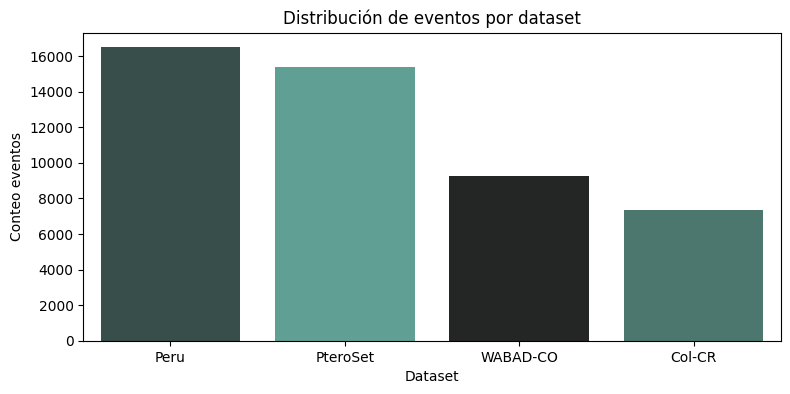

In [25]:
#tamaño figura
plt.figure(figsize=(9, 4))
sns.countplot(master, x="dataset", order=master["dataset"].value_counts().index, palette="dark:#5A9_r", hue="dataset")

plt.title("Distribución de eventos por dataset")
plt.xlabel("Dataset")
plt.ylabel("Conteo eventos")
plt.show()

El corpus está desbalanceado por fuente a nivel de número de eventos. Perú y PteroSet aportan la mayor cantidad de anotaciones, mientras que Col-CR aporta la menor cantidad. Sin embargo, esta diferencia no coincide con la cantidad de horas de audio

## Distribución de grabaciones por especie

In [26]:
master_only_target= master_eda[master_eda["name_specie"] != "OTHER_SPECIES"]
master_only_target= master_only_target[master_only_target["name_specie"] != "UNDEFINED"]
cross_e_d = pd.crosstab(master_eda['name_specie'], master_eda['dataset'])
cross_e_d_alt = pd.crosstab(master_only_target['name_specie'], master_only_target['dataset'])

In [27]:
cross_e_d["total"] = cross_e_d.sum(axis=1)
cross_e_d.sort_values(by="total", ascending=False, inplace=True)
cross_e_d_alt["total"] = cross_e_d_alt.sum(axis=1)
cross_e_d_alt.sort_values(by="total", ascending=False, inplace=True)
display(cross_e_d)
display(cross_e_d_alt)

dataset,Col-CR,Peru,PteroSet,WABAD-CO,total
name_specie,,,,,
OTHER_SPECIES,5173,9617,3418,5111,23319
UNDEFINED,386,1684,8670,0,10740
zonotrichia capensis,762,0,0,406,1168
campylorhynchus turdinus,0,943,9,0,952
cyanocorax violaceus,0,0,914,0,914
cantorchilus leucotis,0,570,4,250,824
crypturellus cinereus,0,372,417,0,789
arremon brunneinucha,248,0,0,469,717
psarocolius angustifrons,12,169,535,0,716


dataset,Col-CR,Peru,PteroSet,WABAD-CO,total
name_specie,,,,,
zonotrichia capensis,762,0,0,406,1168
campylorhynchus turdinus,0,943,9,0,952
cyanocorax violaceus,0,0,914,0,914
cantorchilus leucotis,0,570,4,250,824
crypturellus cinereus,0,372,417,0,789
arremon brunneinucha,248,0,0,469,717
psarocolius angustifrons,12,169,535,0,716
momotus momota,0,450,0,161,611
crypturellus undulatus,0,509,102,0,611


In [28]:
cross_e_d.drop(columns='total', inplace=True) # eliminemos la columna total

La procedencia de los eventos no es homogénea entre las especies objetivo. Algunas clases están completamente o casi completamente asociadas a una única fuente. cyanocorax violaceus procede exclusivamente de PteroSet, colibri cyanotus, atlapetes schistaceus, turdus leucomelas y empidonax virescens proceden exclusivamente de WABAD-CO. Por otro lado, dendrocolaptes certhia, xiphorhynchus guttatus, patagioenas plumbea y campylorhynchus turdinus tienen más del 99 % de sus eventos en Perú.
Esto implica que para varias clases el modelo podría aprender características particulares del dataset de origen además de características de la especie, por lo que deberá vigilarse el domain shift durante la partición y evaluación.

### Distribución de eventos por especie y dataset

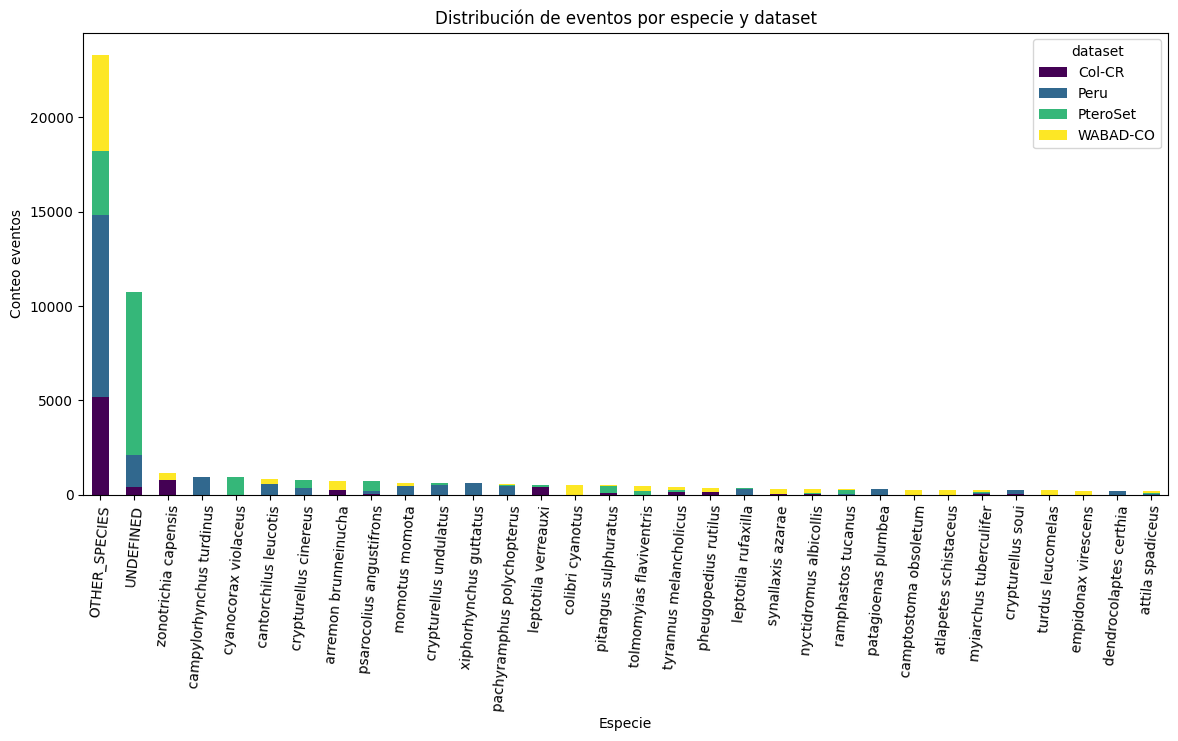

In [29]:


cross_e_d.plot(kind="bar", stacked=True, colormap='viridis', figsize=(14,6))
plt.title("Distribución de eventos por especie y dataset")
plt.xticks(rotation=85)
plt.xlabel("Especie")
plt.ylabel("Conteo eventos")
plt.show()

Los grupos OTHER_SPECIES y UNDEFINED concentran una fracción considerable de los eventos del corpus y están distribuidos de forma desigual entre las fuentes. En particular, los eventos no identificados se concentran principalmente en PteroSet, mientras que OTHER_SPECIES recibe contribuciones de los cuatro datasets.
Para el clasificador, UNDEFINED no constituye una clase de entrenamiento estos eventos se conservan únicamente para el problema de detección.

OTHER_SPECIES domina el corpus maestro en número de eventos, pero este conteo describe el conjunto completo de anotaciones y no debe confundirse con el número definitivo de ejemplos que utilizará el clasificador.

In [30]:
cross_e_d_alt.drop(columns="total", inplace=True) #eliminar total

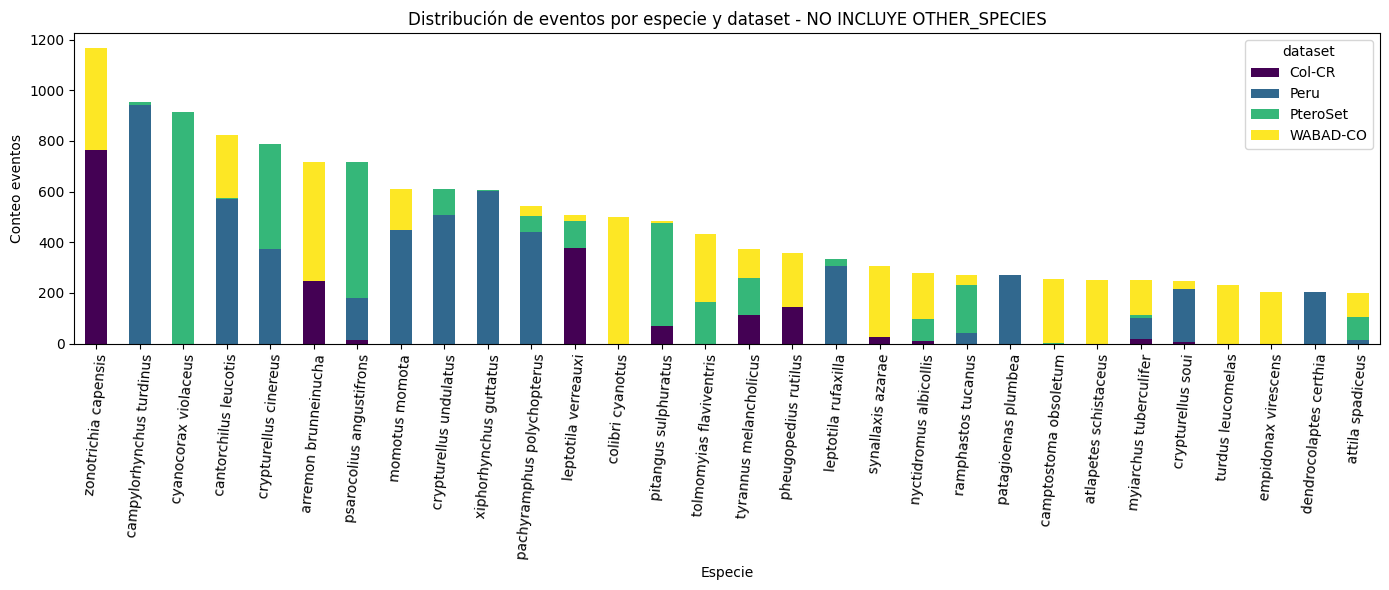

In [31]:
cross_e_d_alt.plot(kind="bar", stacked=True, colormap='viridis', figsize=(14,6))

plt.title("Distribución de eventos por especie y dataset - NO INCLUYE OTHER_SPECIES")
plt.xlabel("Especie")
plt.xticks(rotation=85)
plt.ylabel("Conteo eventos")
plt.tight_layout()
plt.show()

La cobertura entre datasets varía considerablemente según la especie. Algunas clases presentan dependencia prácticamente total de una única fuente, mientras que otras poseen ejemplos provenientes de dos, tres o incluso cuatro datasets.
Entre los casos más extremos están cyanocorax violaceus, representada exclusivamente por PteroSet, colibri cyanotus, atlapetes schistaceus, turdus leucomelas y empidonax virescens, exclusivamente por WABAD-CO, y dendrocolaptes certhia, xiphorhynchus guttatus, patagioenas plumbea y campylorhynchus turdinus, con más del 99 % de sus eventos provenientes de Perú.
En contraste, especies como tyrannus melancholicus, attila spadiceus, crypturellus cinereus y myiarchus tuberculifer presentan una distribución más repartida entre fuentes.

### Diversidad de grabaciones por especie

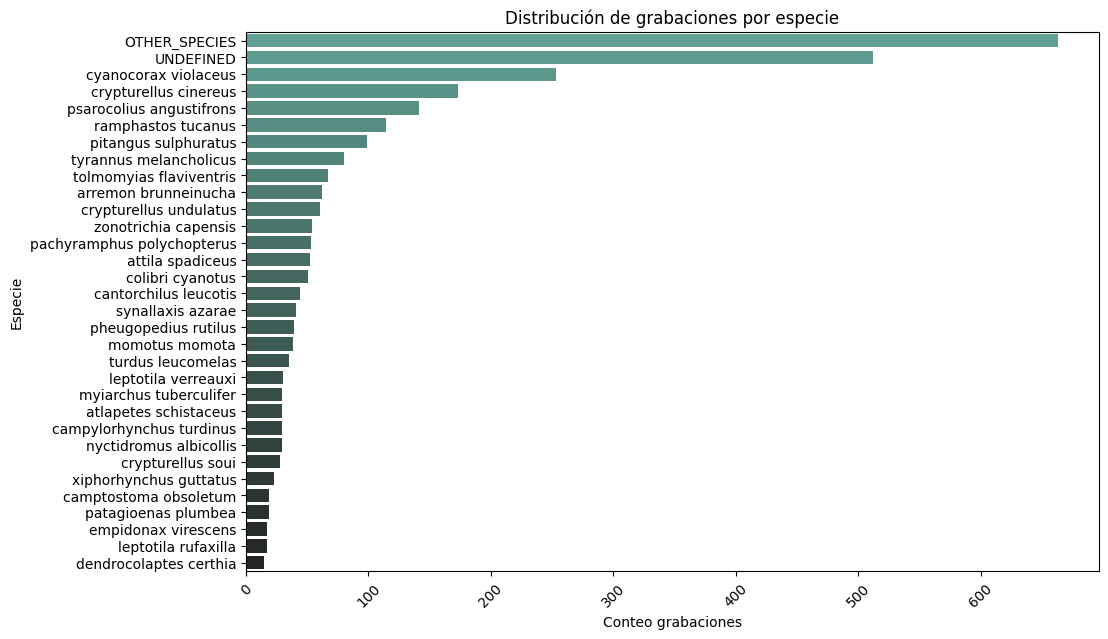

In [32]:
rec_uid_unique = master_eda.groupby("name_specie")["recording_uid"].nunique().reset_index()
rec_uid_unique.sort_values(by="recording_uid", ascending=False, inplace=True)

plt.figure(figsize=(11,7))

sns.barplot(rec_uid_unique, y = "name_specie", x="recording_uid", palette ="dark:#5A9_r", hue = "name_specie")
plt.title("Distribución de grabaciones por especie")
plt.xlabel("Conteo grabaciones")
plt.tick_params(axis='x', rotation=45)
plt.ylabel("Especie")
plt.show()

El número de eventos de una especie no equivale necesariamente a su diversidad de grabaciones. Algunas especies con numerosos eventos se concentran en un número relativamente menor de grabaciones, mientras que otras aparecen distribuidas en una mayor cantidad de recording_uid.
Esto es relevante porque muchos eventos provenientes de pocas grabaciones no proporcionan la misma diversidad acústica que un número similar de eventos repartido entre muchas grabaciones. Por esta razón, la separación de entrenamiento, validación y prueba deberá realizarse por recording_uid y no por evento individual.

In [33]:
df_g_d = (master_eda[["recording_uid", "name_specie", "dataset"]].drop_duplicates(subset=["recording_uid", "name_specie", "dataset"]))
df_g_d

,recording_uid,name_specie,dataset
0,PteroSet::g6455_20240218,OTHER_SPECIES,PteroSet
1,PteroSet::g6455_20240218,cyanocorax violaceus,PteroSet
10,PteroSet::g6455_20240218,psarocolius angustifrons,PteroSet
16,PteroSet::g6455_20240218,ramphastos tucanus,PteroSet
22,PteroSet::g074_timelapse_20250319,UNDEFINED,PteroSet
...,...,...,...
48391,WABAD-CO::ver_20080206_060109,OTHER_SPECIES,WABAD-CO
48400,WABAD-CO::ver_20080206_060200,OTHER_SPECIES,WABAD-CO
48418,WABAD-CO::ver_20080206_060201,OTHER_SPECIES,WABAD-CO
48437,WABAD-CO::ver_20080206_060202,OTHER_SPECIES,WABAD-CO


In [34]:
cross_g_d = pd.crosstab(df_g_d["name_specie"], df_g_d["dataset"])
cross_g_d["total"] = cross_g_d.sum(axis=1)
cross_g_d.sort_values(by="total", ascending=False, inplace=True)
cross_g_d

dataset,Col-CR,Peru,PteroSet,WABAD-CO,total
name_specie,,,,,
OTHER_SPECIES,33,21,224,385,663
UNDEFINED,27,21,464,0,512
cyanocorax violaceus,0,0,253,0,253
crypturellus cinereus,0,16,157,0,173
psarocolius angustifrons,1,14,126,0,141
ramphastos tucanus,0,7,92,15,114
pitangus sulphuratus,12,0,85,2,99
tyrannus melancholicus,12,0,44,24,80
tolmomyias flaviventris,0,0,21,46,67


## Hallazgos de esta primera fase

- Existe una fuerte dependencia entre ciertas especies y el dataset de procedencia. Para varias especies, toda o casi toda la evidencia proviene de una sola fuente, creando riesgo de domain shift y de que el modelo aprenda características del dominio en lugar de las características acústicas de la especie
- El número de eventos es mayor a la cantidad de evidencia independiente. Varias especies poseen cientos de eventos pero relativamente pocas grabaciones distintas, por lo que la futura partición deberá respetar recording_uid para evitar fuga de información

## Duración de eventos

In [35]:
master_eda.columns

Index(['event_id', 'dataset', 'recording', 'recording_key', 'recording_uid',
       'normalized_path', 'recording_duration_sec', 'recording_status',
       'source_group', 'source_archive', 'country', 'species_source_code',
       'species_raw', 'species_scientific', 'identified',
       'taxon_exact_species', 'colombian_evidence', 'is_target', 'class_label',
       'class_code', 't_min', 't_max', 'f_min', 'f_max', 'f_min_original',
       'f_max_original', 'duration_event_sec', 'bandwidth_hz', 'use_detector',
       'use_classifier', 'audio_available', 'name_specie'],
      dtype='object')

In [36]:
# delta_t = tmax - tmin
df_dt = master_eda.copy()
df_dt = df_dt[["recording_uid", "dataset", "name_specie", "t_min", "t_max"]]

In [37]:
df_dt["delta_t"] = df_dt["t_max"] - df_dt["t_min"]
df_dt.sort_values(by="delta_t", inplace=True)
df_dt.head()

,recording_uid,dataset,name_specie,t_min,t_max,delta_t
43710,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,20.462528,15.412403,-5.050126
43707,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,6.315988,1.652284,-4.663704
43709,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,13.564717,9.713830,-3.850887
43712,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,31.688071,28.729950,-2.958121
43713,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,40.965209,39.006453,-1.958756


In [38]:
df_dt[df_dt["delta_t"] < 0].shape

(32, 6)

In [39]:
delta_neg = df_dt[df_dt["delta_t"] < 0]
delta_neg["recording_uid"].nunique()

1

Se encontraron 32 eventos con duración negativa, todos pertenecientes a una única grabación de WABAD-CO. Como $t_{max} < t_{min}$ estas anotaciones son temporalmente inválidas. El hecho de que todas pertenezcan a una misma grabación sugiere un problema localizado en la anotación o en la interpretación de dicha grabación, y no un problema general del corpus

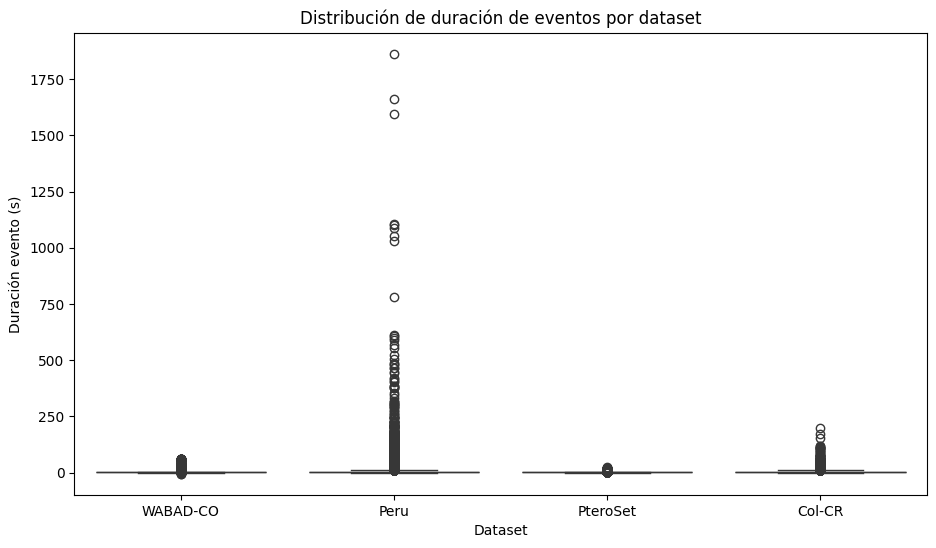

In [40]:
plt.figure(figsize=(11, 6))
sns.boxplot(df_dt, x="dataset", y="delta_t", palette="viridis", hue="dataset")
plt.title("Distribución de duración de eventos por dataset")
plt.xlabel("Dataset")
plt.ylabel("Duración evento (s)")
plt.show()

La duración de los eventos presenta una distribución fuertemente asimétrica hacia la derecha y diferencias considerables entre datasets. Perú concentra los eventos de mayor duración, incluyendo anotaciones de varios cientos o incluso más de mil segundos. Esto puede indicar diferencias en los criterios de anotación entre las fuentes y deberá verificarse antes de considerar estas observaciones como errores

In [41]:
print("PERCENTILES DE delta_t")
# Muestra el DataFrame completo solo dentro de este bloque
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  display(df_dt["delta_t"].quantile(np.arange(0.01, 1.01, 0.01)).T)

PERCENTILES DE delta_t


,delta_t
0.01,0.140015
0.02,0.179805
0.03,0.209941
0.04,0.243448
0.05,0.274352
0.06,0.300000
0.07,0.321770
0.08,0.347137
0.09,0.374593
0.10,0.399173


La mayoría de los eventos son relativamente cortos: el 50 % dura hasta aproximadamente 1.61 s, el 90 % hasta 7.2 s y el 95 % hasta aproximadamente 12 s, aun así existe una cola derecha muy pronunciada, el último 5 % crece desde aproximadamente 12 s hasta valores superiores a mil segundos

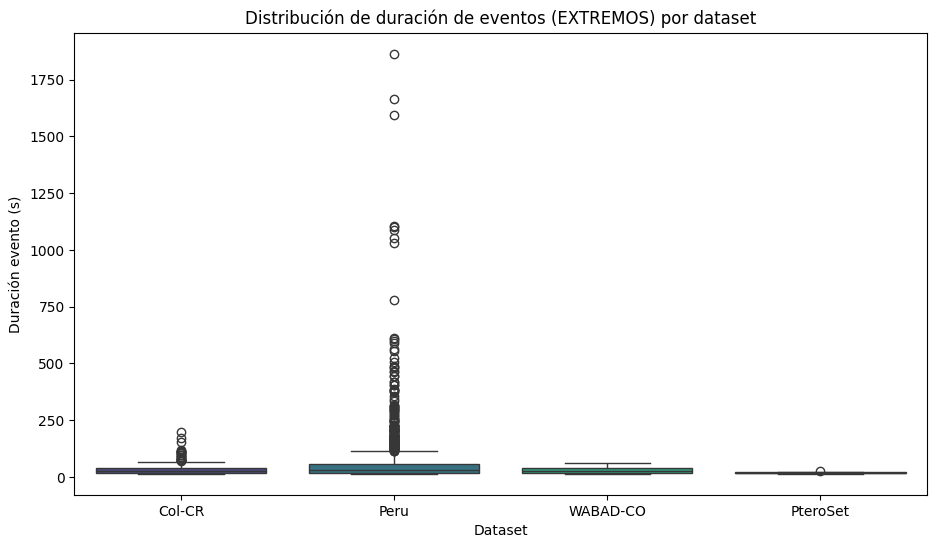

In [42]:
plt.figure(figsize=(11,6))

sns.boxplot(df_dt[df_dt["delta_t"]>14.4], x="dataset", y="delta_t", palette="viridis", hue="dataset")
plt.title("Distribución de duración de eventos (EXTREMOS) por dataset")
plt.xlabel("Dataset")
plt.ylabel("Duración evento (s)")
plt.show()

Se inspecciona la cola superior de la distribución, es decir, aproximadamente al 4 % de eventos con duración superior a 14.4 s, estas muestras son candidatas a ser revisadas

### ¡NOTA!

Las duraciones negativas representan anotaciones inválidas y deben revisarse, las duraciones extremadamente largas no pueden clasificarse automáticamente como errores únicamente por su magnitud, debemos verificar el protocolo de anotación del dataset de origen antes de decidir si se corrigen, eliminan o conservan

In [43]:
df_dt

,recording_uid,dataset,name_specie,t_min,t_max,delta_t
43710,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,20.462528,15.412403,-5.050126
43707,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,6.315988,1.652284,-4.663704
43709,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,13.564717,9.713830,-3.850887
43712,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,31.688071,28.729950,-2.958121
43713,WABAD-CO::spmco_20210416_102000,WABAD-CO,OTHER_SPECIES,40.965209,39.006453,-1.958756
...,...,...,...,...,...,...
24050,Peru::per_002_s02_20190116_100007z,Peru,OTHER_SPECIES,1132.400000,2234.300000,1101.900000
27012,Peru::per_005_s06_20190116_100007z,Peru,OTHER_SPECIES,1804.300000,2910.300000,1106.000000
23433,Peru::per_001_s01_20190116_100007z,Peru,leptotila rufaxilla,499.700000,2094.600000,1594.900000
35848,Peru::per_016_s02_20190131_100007z,Peru,OTHER_SPECIES,1767.700000,3432.300000,1664.600000


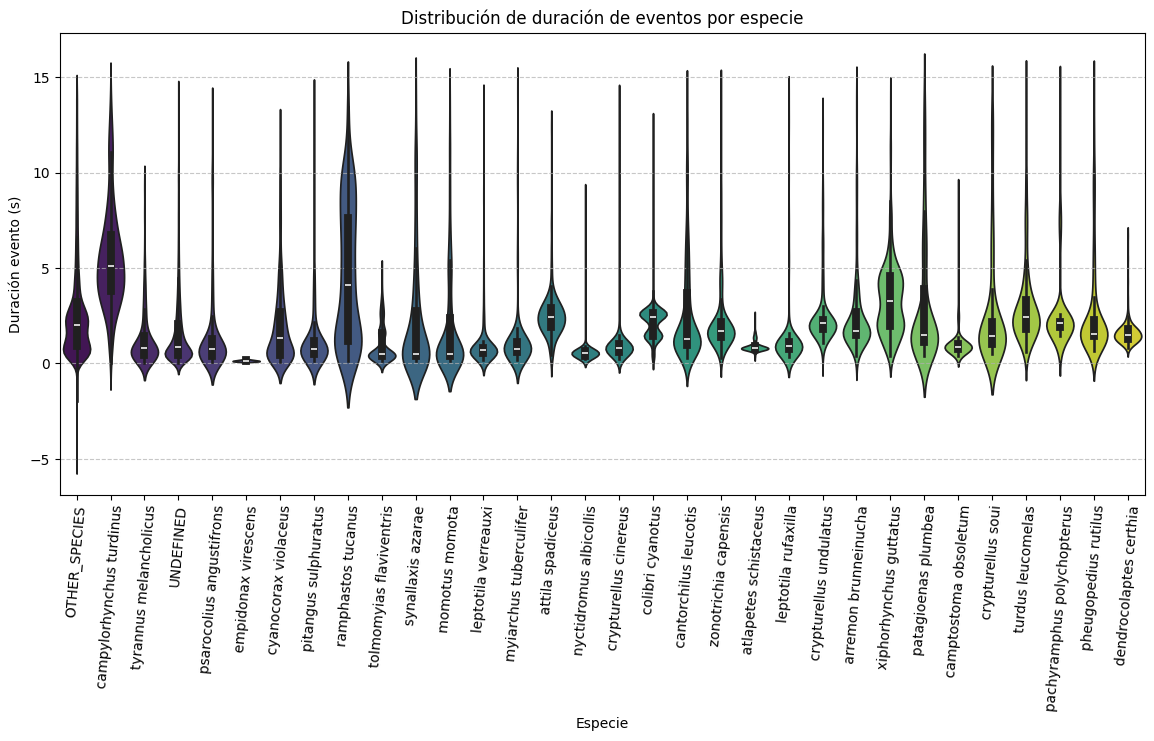

In [44]:
plt.figure(figsize=(14,6))

sns.violinplot(df_dt[df_dt["delta_t"]<14.4], x="name_specie", y="delta_t", palette="viridis", hue="name_specie")
plt.title("Distribución de duración de eventos por especie")
plt.xlabel("Especie")
plt.xticks(rotation=85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel("Duración evento (s)")
plt.show()

La mayor parte de los eventos válidos es corta: aproximadamente el 90 % de las anotaciones globales tiene una duración inferior a 7.2 s y el 95 % inferior a aproximadamente 12 s.

la distribución depende de la especie, por lo que la selección futura de una duración fija de entrada deberá evaluar cuánto porcentaje de eventos de cada especie quedaría completamente contenido en dicha ventana.

In [45]:
df_dt.groupby("dataset")["delta_t"].describe()

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
Col-CR,7338.0,4.950940,9.820439,0.100000,0.800000,1.700000,4.800000,197.000000
Peru,16482.0,8.185942,40.431362,0.000000,1.600000,2.500000,4.800000,1863.900000
PteroSet,15372.0,1.697219,2.139942,0.040179,0.429011,0.818422,2.091993,26.965501
WABAD-CO,9273.0,1.882924,3.834558,-5.050126,0.667752,1.356397,2.003852,59.976413


La duración de los eventos depende fuertemente del dataset de origen. Perú presenta la mayor mediana y una cola extremadamente larga, mientras PteroSet presenta anotaciones considerablemente más cortas. Esto sugiere que las fuentes pueden utilizar criterios o granularidades de anotación diferentes, lo cual deberá considerarse durante el preprocesamiento y la selección de la duración de las ventanas

In [46]:
df_dt.groupby("name_specie")["delta_t"].describe().sort_values(by="max", ascending=False)

,count,mean,std,min,25%,50%,75%,max
name_specie,,,,,,,,
UNDEFINED,10740.0,2.243726,18.950367,0.050203,0.456394,0.899861,2.100000,1863.900000
OTHER_SPECIES,23319.0,5.567376,26.930507,-5.050126,1.000000,2.100000,3.700000,1664.600000
leptotila rufaxilla,332.0,14.382009,92.610665,0.346860,0.800000,0.900000,1.200000,1594.900000
ramphastos tucanus,272.0,18.457153,78.698577,0.107169,1.409437,5.126483,9.437451,1053.500000
crypturellus soui,248.0,16.438517,53.537289,0.500000,1.100000,1.700000,9.975000,596.700000
cantorchilus leucotis,824.0,6.871104,31.760613,0.293160,0.990410,1.400000,4.700000,588.900000
psarocolius angustifrons,716.0,3.699765,22.451734,0.053584,0.409508,0.795755,1.400679,486.900000
patagioenas plumbea,271.0,8.913412,25.048519,0.400000,1.200000,1.600000,6.350000,271.100000
momotus momota,611.0,3.771341,15.357844,0.122150,0.400000,0.600000,2.850000,261.300000


Las especies objetivo presentan patrones temporales considerablemente diferentes. Algunas, como `empidonax virescens`, contienen eventos de apenas décimas de segundo, mientras que especies como `campylorhynchus turdinus` y `ramphastos tucanus` presentan eventos típicos de varios segundos. Por tanto, la duración de la ventana de entrada no debe seleccionarse únicamente a partir de la distribución global, sino evaluando la cobertura obtenida para cada especie.

## Ventanas candidatas

$$C(L)=\frac{\#EventosConΔt<L}{\#Eventos}$$

In [47]:
df_dt_valid = df_dt[df_dt["delta_t"] > 0].copy()
ventanas = [1, 2, 3, 5, 8, 10, 12, 15]
cobertura_global = pd.DataFrame({
    "ventana(s)": ventanas,
    "cobertura_pct": [(df_dt_valid["delta_t"] <= ventana).mean() *100 for ventana in ventanas]
})

In [48]:
cobertura_global

,ventana(s),cobertura_pct
0,1,35.359584
1,2,57.979393
2,3,74.485350
3,5,85.131424
4,8,91.329933
5,10,93.714769
6,12,95.027978
7,15,96.260659


La cobertura temporal aumenta rápidamente hasta ventanas de aproximadamente 5–8 s y posteriormente presenta rendimientos decrecientes. Aumentar de 10 a 15 s incrementaría en un 50 % la longitud temporal de entrada para recuperar únicamente unos 2.5 puntos porcentuales adicionales de eventos completos, por esto, el intervalo de 8–12 s es una región razonable para evaluar posteriormente como duración de entrada del modelo.

In [49]:
cobertura_especies = df_dt_valid.groupby("name_specie")["delta_t"].apply(
    lambda x: pd.Series({f"{ventana}s": (x <= ventana).mean() * 100 for ventana in ventanas})
)
cobertura_especies

name_specie              
OTHER_SPECIES         1s     25.976982
                      2s     47.466289
                      3s     69.436571
                      5s     81.469553
                      8s     88.405050
                               ...    
zonotrichia capensis  5s     86.044521
                      8s     90.325342
                      10s    91.952055
                      12s    92.465753
                      15s    93.578767
Name: delta_t, Length: 256, dtype: float64

In [50]:
cobertura_especies = cobertura_especies.unstack()
cobertura_especies.sort_values("5s")

,1s,2s,3s,5s,8s,10s,12s,15s
name_specie,,,,,,,,
campylorhynchus turdinus,1.577287,4.942166,12.828601,45.741325,79.705573,85.594111,90.956887,94.637224
ramphastos tucanus,16.176471,31.985294,37.132353,48.897059,66.544118,80.147059,84.558824,86.764706
crypturellus soui,20.564516,58.467742,62.903226,66.935484,72.983871,75.000000,77.419355,80.645161
patagioenas plumbea,13.284133,60.885609,63.468635,69.372694,78.966790,82.287823,85.239852,88.191882
cantorchilus leucotis,29.247573,58.009709,65.898058,76.941748,86.407767,88.592233,90.898058,92.597087
synallaxis azarae,54.248366,62.745098,71.241830,80.392157,86.274510,89.215686,93.137255,94.771242
OTHER_SPECIES,25.976982,47.466289,69.436571,81.469553,88.405050,91.290904,93.133213,94.889633
momotus momota,64.975450,69.885434,75.286416,82.160393,90.834697,93.126023,94.926350,96.072013
leptotila rufaxilla,64.457831,83.132530,83.734940,84.036145,86.445783,86.445783,86.746988,87.951807


In [51]:
resumen_cobertura = pd.DataFrame({
    "ventanas(s)": ventanas,
    "peor_especie": [cobertura_especies[f"{ventana}s"].idxmin() for ventana in ventanas],
    "min_cobertura_pct": [cobertura_especies[f"{ventana}s"].min() for ventana in ventanas],
    "median_cobertura_pct": [cobertura_especies[f"{ventana}s"].median() for ventana in ventanas],
    "max_cobertura_pct": [cobertura_especies[f"{ventana}s"].max() for ventana in ventanas],
})
print("\n\t\t\t\t\tMEDIAN Y MAX NO CORRESPONDEN A LA ESPECIE, UNICAMENTE MIN")
resumen_cobertura


					MEDIAN Y MAX NO CORRESPONDEN A LA ESPECIE, UNICAMENTE MIN


,ventanas(s),peor_especie,min_cobertura_pct,median_cobertura_pct,max_cobertura_pct
0,1,crypturellus undulatus,1.145663,36.997966,100.0
1,2,campylorhynchus turdinus,4.942166,68.415520,100.0
2,3,campylorhynchus turdinus,12.828601,83.636557,100.0
3,5,campylorhynchus turdinus,45.741325,90.447247,100.0
4,8,ramphastos tucanus,66.544118,94.727961,100.0
5,10,crypturellus soui,75.000000,96.229050,100.0
6,12,crypturellus soui,77.419355,97.332287,100.0
7,15,crypturellus soui,80.645161,98.064496,100.0


A 5 segundos globalmente hay 85.13%, esto parece bueno, pero algunas especies:
- campylorhynchus turdinus 45.74 %
- ramphastos tucanus 48.90 %
- crypturellus soui 66.94 %
- patagioenas plumbea 69.37 %
- cantorchilus leucotis 76.94 %

Por tanto, una ventana de 5 s sería engañosamente buena si miráramos únicamente el promedio global. Para `campylorhynchus turdinus`, más de la mitad de las anotaciones duran más de 5 s

Para 8 segundos las especies mas dificles quedan:
- ramphastos tucanus 66.54 %
- crypturellus soui 72.98 %
- patagioenas plumbea 78.97 %
- campylorhynchus turdinus 79.71 %
- cantorchilus leucotis 86.41 %

Además la mediana es 94.72%, es decir, que la mitad de las especies tiene una cobertura superior aproximadamente al 94.7 % con 8 s.

Con 10 segundos:
- crypturellus soui 75.00 %
- ramphastos tucanus 80.15 %
- patagioenas plumbea 82.29 %
- campylorhynchus turdinus 85.59 %
- leptotila rufaxilla 86.45 %
Y la mediana entre especies es 96.23%, aunque el salto de 8 a 10 segundos solo ganó aproximadamente 1.5 puntos porcentuales

Con 12 segundos simplemente se ganaron 1.2 puntos porcentuales, ya comenzaria a decrecer nuevamente la ganancia

Se considera como posbiles candidadtos 8s, 10s y 12s

In [52]:
96.23-94.72

1.5100000000000051

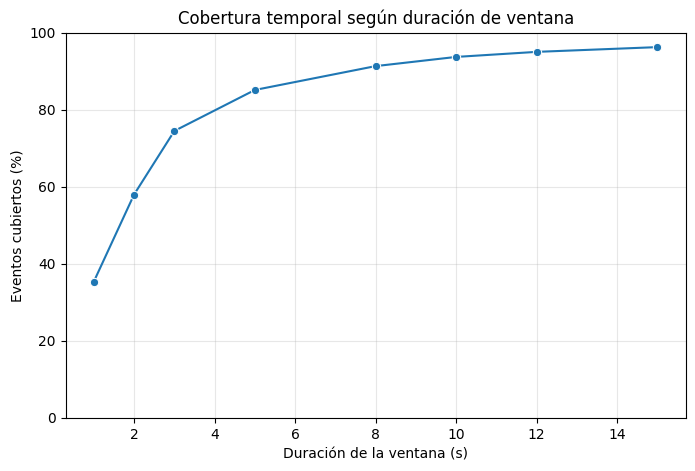

In [53]:
plt.figure(figsize=(8, 5))

sns.lineplot(data=cobertura_global, x="ventana(s)", y="cobertura_pct", marker="o" )

plt.xlabel("Duración de la ventana (s)")
plt.ylabel("Eventos cubiertos (%)")
plt.title("Cobertura temporal según duración de ventana")
plt.ylim(0, 100)
plt.grid(alpha=0.3)

plt.show()

Este gráfico refuerza a 8s, 10s y quizas 12s como excelentes candidatos

## Frecuencias

In [54]:
df_f = master_eda.copy()
df_f = df_f[["recording_uid", "dataset", "name_specie", "t_min", "t_max", "f_min", "f_max", "f_min_original", "f_max_original"]]

In [55]:
df_f["delta_f"] = df_f["f_max"] - df_f["f_min"]
df_f.sort_values(by="delta_f", inplace=True)
df_f.sort_values(by="delta_f", inplace=True, ascending=False)
df_f.reset_index(drop=True, inplace=True)
display(df_f.shape)
df_f.head()

(48465, 10)

,recording_uid,dataset,name_specie,t_min,t_max,f_min,f_max,f_min_original,f_max_original,delta_f
0,PteroSet::g010_timelapse_20250622,PteroSet,OTHER_SPECIES,159.842088,170.043658,0.0,16000.0,0.0,24000.0,16000.0
1,PteroSet::g6394_20240218,PteroSet,ramphastos tucanus,260.937453,271.146514,0.0,16000.0,0.0,16826.6,16000.0
2,PteroSet::g6418_20240220,PteroSet,OTHER_SPECIES,152.922231,154.837946,0.0,16000.0,0.0,16349.7,16000.0
3,PteroSet::g6398_20240220,PteroSet,OTHER_SPECIES,164.189621,171.949478,0.0,16000.0,0.0,16079.5,16000.0
4,PteroSet::g6370_20240219,PteroSet,OTHER_SPECIES,135.428718,143.709940,0.0,16000.0,0.0,20276.5,16000.0


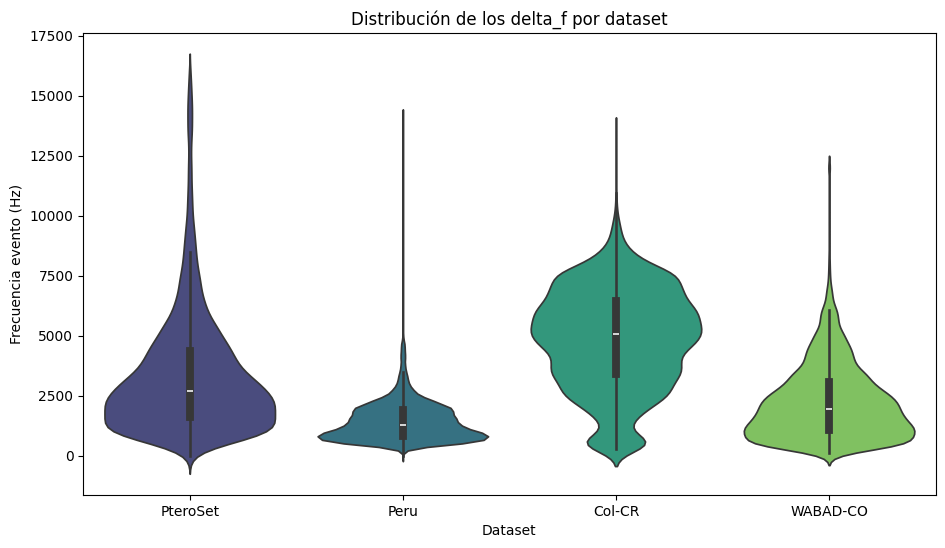

In [56]:
plt.figure(figsize=(11,6))

sns.violinplot(df_f, x="dataset", y="delta_f", palette="viridis", hue="dataset")
plt.title("Distribución de los delta_f por dataset")
plt.xlabel("Dataset")
plt.ylabel("Frecuencia evento (Hz)")
plt.show()

La amplitud espectral de las anotaciones varía considerablemente entre fuentes. Col-CR presenta generalmente bandas de frecuencia más amplias, mientras Perú y WABAD-CO concentran gran parte de sus eventos en anchos menores. Esta diferencia puede reflejar características acústicas del contenido, pero también diferencias en los criterios utilizados para delimitar espectralmente los eventos.

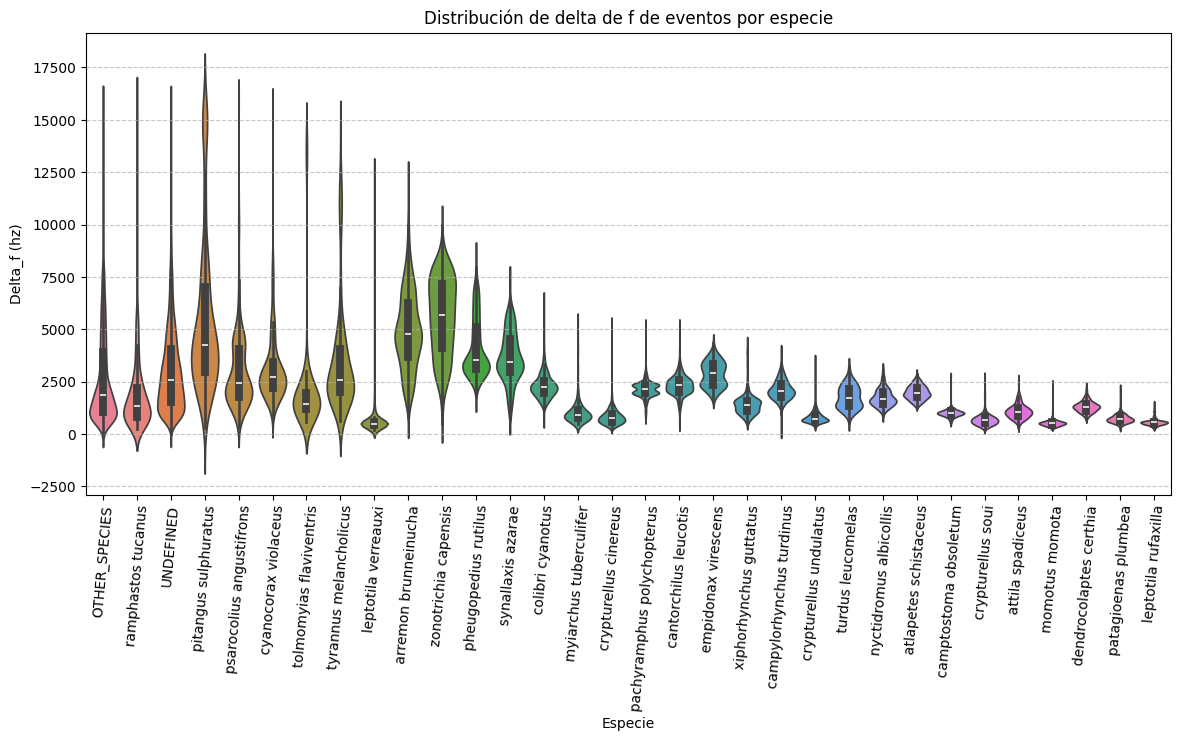

In [57]:
plt.figure(figsize=(14,6))
sns.violinplot(df_f, x="name_specie", y = "delta_f", hue="name_specie")
plt.title("Distribución de delta de f de eventos por especie")
plt.xlabel("Especie")
plt.xticks(rotation=85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylabel("Delta_f (hz)")
plt.show()

In [58]:
print("f_min < 0:",(df_f["f_min"] < 0).sum())
print("f_max < 0:",(df_f["f_max"] < 0).sum())
print("f_max < f_min:",(df_f["f_max"] < df_f["f_min"]).sum())
print("delta_f == 0:",(df_f["delta_f"] == 0).sum())
print("delta_f < 0:",(df_f["delta_f"] < 0).sum())
print("f_max > 16000:",(df_f["f_max"] > 16000).sum())

f_min < 0: 0
f_max < 0: 0
f_max < f_min: 0
delta_f == 0: 2
delta_f < 0: 0
f_max > 16000: 0


Las anotaciones espectrales presentan buena consistencia general: no se encontraron frecuencias negativas ni intervalos con $f_{max}<f_{min}$ Solo se detectaron dos eventos con ancho de banda nulo ($Δ f = 0$) los cuales deben revisarse individualmente.

In [59]:
# mostrar todas las columnas
pd.set_option('display.max_columns', None)
df_f.groupby("dataset")[["f_min", "f_max", "delta_f"]].describe()

f_min                                                         \
            count         mean          std  min     25%     50%     75%   
dataset                                                                    
Col-CR     7338.0  2187.643772  1833.347266  0.0   847.0  1694.0  3235.0   
Peru      16482.0  1318.193909   784.709138  0.0   833.0  1299.0  1601.0   
PteroSet  15372.0  1702.645645  1246.974924  0.0   793.0  1411.8  2258.8   
WABAD-CO   9273.0  2827.259326  1878.909217  0.0  1411.8  2357.9  3957.9   

                       f_max                                               \
                max    count         mean          std      min       25%   
dataset                                                                     
Col-CR    10463.000   7338.0  7053.656855  2816.251999  490.000  5084.000   
Peru      11465.000  16482.0  2748.575537  1110.836469  263.000  2063.000   
PteroSet  10309.200  15372.0  5091.125688  2872.783744  543.900  2936.575   
WABAD-CO   9479.439   9273.0  5068.282070  2796.594221  359.065  3038.400   

                                    delta_f                            \
             50%      75%      max    count         mean          std   
dataset                                                                 
Col-CR    7800.0  9132.25  16000.0   7338.0  4866.013083  2098.921439   
Peru      2604.0  3432.00  14930.0  16482.0  1430.381628   790.688166   
PteroSet  4743.5  6381.20  16000.0  15372.0  3388.480043  2577.101005   
WABAD-CO  4498.8  6924.00  13785.2   9273.0  2241.022743  1542.931545   

                                                         
              min      25%       50%       75%      max  
dataset                                                  
Col-CR    277.000  3389.25  5066.000  6441.000  13392.0  
Peru        0.000   833.00  1270.000  1898.000  14206.0  
PteroSet    0.000  1618.95  2710.600  4373.825  16000.0  
WABAD-CO  104.502  1053.20  1933.294  3068.500  12000.0

Los datasets no solo difieren en duración de eventos, sino también en cómo ocupan el espectro. Col-CR presenta anotaciones considerablemente más anchas y con frecuencias máximas más elevadas, mientras Perú concentra la mayor parte de sus eventos en bandas relativamente estrechas y de menor frecuencia. Esto sugiere diferencias acústicas reales entre las fuentes o diferencias en los criterios de anotación espectral.

In [60]:
pd.set_option('display.max_columns', None)
df_f.groupby("name_specie")[["f_min", "f_max", "delta_f"]].describe()

f_min                                      \
                              count         mean          std       min   
name_specie                                                               
OTHER_SPECIES               23319.0  1983.715890  1475.568001     0.000   
UNDEFINED                   10740.0  1738.941758  1277.291885     0.000   
arremon brunneinucha          717.0  5770.038967  1842.999898     0.000   
atlapetes schistaceus         252.0  2558.829282   347.352679  1909.091   
attila spadiceus              200.0  1698.237000   234.809462   941.200   
camptostoma obsoletum         255.0  3177.802353   119.226653  2792.800   
campylorhynchus turdinus      952.0   430.621849   272.450040     0.000   
cantorchilus leucotis         824.0  1244.911044   327.765639     0.000   
colibri cyanotus              498.0  5295.740865   361.321154  3011.800   
crypturellus cinereus         789.0  1336.187579   232.151155   119.800   
crypturellus soui             248.0  1369.057661   244.420809   169.000   
crypturellus undulatus        611.0   872.833224   148.328717   179.100   
cyanocorax violaceus          914.0  1737.476477   475.278033   101.500   
dendrocolaptes certhia        204.0  1134.533333   164.568985   593.000   
empidonax virescens           205.0  3268.886678   578.225079  1921.789   
leptotila rufaxilla           332.0   238.728012   180.744783     0.000   
leptotila verreauxi           506.0   226.357587   118.138045     0.000   
momotus momota                611.0   196.142226   103.826622     0.000   
myiarchus tuberculifer        252.0  1897.508730   369.239983     0.000   
nyctidromus albicollis        279.0   852.030824   254.943602     0.000   
pachyramphus polychopterus    541.0  1567.458410   214.511846   648.000   
patagioenas plumbea           271.0   315.655351   117.178332    79.000   
pheugopedius rutilus          358.0  1447.927654   426.365099     0.000   
pitangus sulphuratus          482.0  1520.914873   772.144442     0.000   
psarocolius angustifrons      716.0   486.163547   365.583849     0.000   
ramphastos tucanus            272.0   790.403309   354.185634     0.000   
synallaxis azarae             306.0  1416.044275   493.620283   520.000   
tolmomyias flaviventris       431.0  4309.741763   654.948928  1564.900   
turdus leucomelas             233.0  1481.462661   184.905499   920.700   
tyrannus melancholicus        374.0  3888.480463   985.265799   491.000   
xiphorhynchus guttatus        605.0  1067.314215   237.620331   158.000   
zonotrichia capensis         1168.0  1969.077550   757.176300     0.000   

                                                                       \
                                  25%        50%       75%        max   
name_specie                                                             
OTHER_SPECIES               1081.0405  1552.9410  2579.000   8897.000   
UNDEFINED                    841.1000  1411.8000  2299.700  11465.000   
arremon brunneinucha        4298.0000  6382.2710  6993.865   9479.439   
atlapetes schistaceus       2425.7290  2532.0525  2680.257   6581.560   
attila spadiceus            1565.2000  1749.4000  1863.950   2281.000   
camptostoma obsoletum       3099.7000  3191.8000  3253.200   3560.100   
campylorhynchus turdinus     282.0000   396.0000   515.000   3073.000   
cantorchilus leucotis       1037.7500  1196.9000  1428.000   2658.000   
colibri cyanotus            5218.3290  5309.2695  5409.463   7884.700   
crypturellus cinereus       1242.4000  1355.3000  1467.200   2823.500   
crypturellus soui           1269.0000  1382.0000  1507.000   1818.000   
crypturellus undulatus       807.0000   887.0000   952.000   2369.500   
cyanocorax violaceus        1420.8250  1796.9000  2057.100   4009.400   
dendrocolaptes certhia      1031.0000  1150.0000  1234.000   1587.000   
empidonax virescens         2813.8050  3245.6780  3733.867   4678.781   
leptotila rufaxilla          188.0000   228.0000   277.000   3174.000   
leptotila verreau

Las especies objetivo presentan regiones espectrales muy diferentes. Algunas vocalizaciones se concentran por debajo de 1 kHz, mientras otras se sitúan predominantemente entre aproximadamente 4 y 11 kHz

No sería adecuado restringir agresivamente el espectrograma a una banda estrecha común sin que antes se osberve que especies quedarían afectadas.

In [61]:
above_nyquist = df_f["f_max_original"] > 16000
print("Eventos cuyo f_max_original superaba 16 kHz:")
print(above_nyquist.sum())
print("Porcentaje:",above_nyquist.mean() * 100)

Eventos cuyo f_max_original superaba 16 kHz:
272
Porcentaje: 0.5612297534303106


In [62]:
(df_f[above_nyquist].groupby("name_specie").size().sort_values(ascending=False))

,0
name_specie,
OTHER_SPECIES,166
pitangus sulphuratus,41
tyrannus melancholicus,27
tolmomyias flaviventris,17
UNDEFINED,15
cyanocorax violaceus,4
ramphastos tucanus,1
psarocolius angustifrons,1


el remuestreo a 32 kHz parece razonable a nivel global, aunque algunas clases pierden parcialmente contenido de alta frecuencia.

In [63]:
completely_above_nyquist = (df_f["f_min_original"] >= 16000)

print(f"Eventos completamente por encima de 16 kHz: {completely_above_nyquist.sum()}")
print(f"Porcentaje: {completely_above_nyquist.mean() * 100}")

Eventos completamente por encima de 16 kHz: 0
Porcentaje: 0.0


El remuestreo a 32 kHz no elimina por completo ningún evento anotado.

$f_{max,original}> 16000 hz$ no quiere decir que el 8.5 % de sus eventos haya desaparecido. Solo significa que esos eventos tenían alguna parte superior de su banda por encima de 16 kHz.

In [64]:
(df_f[completely_above_nyquist].groupby("name_specie").size().sort_values(ascending=False))

,0
name_specie,


In [65]:
frec_limites = [4000, 6000, 8000, 10000, 11000, 12000, 14000, 16000]

frec_cobertura_global = pd.DataFrame({
    "fmax_hz": frec_limites,
    "coverage_pct": [(df_f["f_max"] <= frec).mean() * 100 for frec in frec_limites]
})

frec_cobertura_global

,fmax_hz,coverage_pct
0,4000,51.981843
1,6000,72.772104
2,8000,85.911483
3,10000,95.415248
4,11000,97.550810
5,12000,98.858970
6,14000,99.323223
7,16000,100.000000


La mayor parte del contenido anotado se encuentra por debajo de 10–12 kHz. Un límite superior de 10 kHz contiene por completo aproximadamente el 95.4 % de los eventos, mientras que 12 kHz aumenta la cobertura a 98.9 %. A partir de 12 kHz la mejora global es marginal.

In [66]:
frec_cobertura_especies = (
    df_f.groupby("name_specie")["f_max"]
    .apply(lambda s: pd.Series({f"{frec/1000:.0f}kHz": (s <= frec).mean() * 100 for frec in frec_limites})).unstack()
)

frec_cobertura_especies

,4kHz,6kHz,8kHz,10kHz,11kHz,12kHz,14kHz,16kHz
name_specie,,,,,,,,
OTHER_SPECIES,53.642952,70.757751,81.675887,95.128436,97.302629,98.601998,99.202367,100.0
UNDEFINED,40.670391,72.905028,90.772812,96.759777,98.603352,99.385475,99.711359,100.0
arremon brunneinucha,0.139470,0.278940,0.557880,20.641562,61.785216,94.839609,99.442120,100.0
atlapetes schistaceus,0.793651,99.603175,99.603175,100.000000,100.000000,100.000000,100.000000,100.0
attila spadiceus,99.500000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
camptostoma obsoletum,11.372549,99.607843,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
campylorhynchus turdinus,99.054622,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
cantorchilus leucotis,86.407767,99.878641,100.000000,100.000000,100.000000,100.000000,100.000000,100.0
colibri cyanotus,0.000000,0.000000,82.329317,99.196787,100.000000,100.000000,100.000000,100.0


A `fmax = 10 kHz`, la mayoría de las especies ya tiene cobertura altísima, pero:

`arremon brunneinucha`: 20.64%

pero con 12kHz -> 94.84%

Ese dato por sí solo descarta 10 kHz como límite superior general en el caso de que se desee preservar todas las especies.


**CANDIDATOS** pueden ser 10, 11, 12, 14 y 16 kHz

La mayor candidata es 16kHz porque ya se tiene audio a 32 kHz. Nyquist ya limita físicamente el sistema a 16 kHz, así que usar fmax=16 kHz no añade información artificial, simplemente no se descarta información que ya se conserva

Para limites inferiores

In [67]:
frec_min_candidatos = [0, 100, 200, 300, 500, 800, 1000]

inferior = pd.DataFrame({
    "fmin_hz": frec_min_candidatos,
    "events_affected_pct": [(df_f["f_min"] < frec).mean() * 100 for frec in frec_min_candidatos]
})

inferior

,fmin_hz,events_affected_pct
0,0,0.000000
1,100,2.067471
2,200,4.815846
3,300,8.172908
4,500,13.186836
5,800,21.258640
6,1000,28.298772


Esta tabla no aporta candidatos claves

In [68]:
frec_min_candidatos = [100, 200, 300, 500, 800, 1000]

resumen_corte_bajo = pd.DataFrame({
    "fmin_hz": frec_min_candidatos,
    "parcialmente_afectado_pct": [(df_f["f_min"] < frec).mean() * 100 for frec in frec_min_candidatos],
    "completamente_por_debajo_pct": [(df_f["f_max"] <= frec).mean() * 100 for frec in frec_min_candidatos]
})

resumen_corte_bajo

,fmin_hz,parcialmente_afectado_pct,completamente_por_debajo_pct
0,100,2.067471,0.000000
1,200,4.815846,0.000000
2,300,8.172908,0.002063
3,500,13.186836,0.247601
4,800,21.258640,3.208501
5,1000,28.298772,4.450634


In [69]:
corte_bajo_especies = (df_f.groupby("name_specie").apply(
        lambda g: pd.Series({
            f"{frec}Hz_affected": (g["f_min"] < frec).mean() * 100 for frec in [100, 200, 300, 500, 800, 1000]
        } | {
            f"{frec}Hz_lost": (g["f_max"] <= frec).mean() * 100 for frec in [100, 200, 300, 500, 800, 1000]
        })
    )
)

corte_bajo_especies

/tmp/ipykernel_969/2138693812.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corte_bajo_especies = (df_f.groupby("name_specie").apply(


,100Hz_affected,200Hz_affected,300Hz_affected,500Hz_affected,800Hz_affected,1000Hz_affected,100Hz_lost,200Hz_lost,300Hz_lost,500Hz_lost,800Hz_lost,1000Hz_lost
name_specie,,,,,,,,,,,,
OTHER_SPECIES,2.693083,4.344097,6.295296,9.695956,16.214246,21.780522,0.0,0.0,0.004288,0.458853,1.711051,2.255671
UNDEFINED,1.135940,2.476723,4.599628,10.763501,23.854749,32.672253,0.0,0.0,0.000000,0.018622,0.288641,1.070764
arremon brunneinucha,0.139470,0.139470,0.139470,0.139470,0.139470,0.139470,0.0,0.0,0.000000,0.000000,0.000000,0.000000
atlapetes schistaceus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
attila spadiceus,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
camptostoma obsoletum,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
campylorhynchus turdinus,1.995798,10.609244,25.525210,71.638655,97.163866,98.109244,0.0,0.0,0.000000,0.000000,0.000000,0.000000
cantorchilus leucotis,0.364078,0.485437,0.485437,1.092233,5.461165,20.631068,0.0,0.0,0.000000,0.000000,0.000000,0.000000
colibri cyanotus,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000


Idealmente queremos encontrar una frecuencia relativamente alta donde las muestras o especies afectadas sean lo mas bajas posibles al igual que las perdidas/completamente abajo, es decir:

parcialmente afectados:  0 %

Completamente perdidos:  0 %

A partir de 300–500 Hz el impacto aumenta considerablemente para especies de baja frecuencia como `momotus momota`, `leptotila rufaxilla`, `leptotila verreauxi` y `patagioenas plumbea`. Cortes de 800 Hz o superiores resultarían particularmente perjudiciales, llegando a eliminar completamente la mayoría de los eventos de algunas de estas especies. Por tanto, 0, 100 y 200 Hz constituyen límites inferiores razonables para futuros experimentos, siendo 0 Hz la configuración conservadora de referencia.

Podemos concluir esta sección con:

Los mayores candidatos para frecuencia son aquellos que no dejan información fuera
$$f_{min} = 0kHz$$
$$f_{max} = 16kHz$$

Y es comprensible, pues ya muchas decenes de kHz se han "descartado" cuando se realizó la normalizacion

aunque otras posibles candidatas son:
$$f_{min} ∈ \{0, 100, 200\} Hz$$
$$f_{max} ∈ \{12, 14, 16\} kHz$$

## Coocurrencia y solapamiento temporal

In [70]:
master_overlap = master_eda[(master_eda["use_detector"] == True) & (master_eda["t_max"] > master_eda["t_min"])].copy()

master_overlap["species_event"] = np.where(master_overlap["identified"] & master_overlap["species_scientific"].notna(), master_overlap["species_scientific"], "UNDEFINED")

aux = master_overlap.copy()


def analizar_solapamiento(aux, events):
    results = []

    events_by_recording = {
        uid: g
        for uid, g in events.groupby("recording_uid")
    }

    for _, a in aux.iterrows():
        g = events_by_recording[a["recording_uid"]]

        overlap = g[(g["event_id"] != a["event_id"]) & (g["t_min"] < a["t_max"]) & (g["t_max"] > a["t_min"])]

        different_species = overlap[overlap["species_event"] != a["species_event"]]

        results.append({
            "event_id": a["event_id"],
            "name_specie": a["name_specie"],
            "dataset": a["dataset"],
            "has_overlap": len(overlap) > 0,
            "has_different_species_overlap": len(different_species) > 0,
            "n_overlapping_events": len(overlap),
            "n_different_species": different_species["species_event"].nunique()
        })

    return pd.DataFrame(results)


solapamiento_result = analizar_solapamiento(aux, master_overlap)

solapamiento_result[solapamiento_result["has_overlap"]].head()

,event_id,name_specie,dataset,has_overlap,has_different_species_overlap,n_overlapping_events,n_different_species
15,PteroSet::15,cyanocorax violaceus,PteroSet,True,True,1,1
16,PteroSet::16,ramphastos tucanus,PteroSet,True,True,1,1
19,PteroSet::19,cyanocorax violaceus,PteroSet,True,True,1,1
20,PteroSet::20,psarocolius angustifrons,PteroSet,True,True,1,1
59,PteroSet::59,UNDEFINED,PteroSet,True,False,1,0


In [71]:
solapamiento_resumen = pd.Series({
    "eventos_detector": len(solapamiento_result),
    "eventos_con_solapamiento_pct": solapamiento_result["has_overlap"].mean() * 100,
    "eventos_con_otra_especie_pct": solapamiento_result["has_different_species_overlap"].mean() * 100,
    "promedio_eventos_solapados": solapamiento_result["n_overlapping_events"].mean(),
    "promedio_especies_distintas": solapamiento_result["n_different_species"].mean()
})

solapamiento_resumen

,0
eventos_detector,48430.000000
eventos_con_solapamiento_pct,53.557712
eventos_con_otra_especie_pct,51.940946
promedio_eventos_solapados,1.584720
promedio_especies_distintas,1.210118


De 48.430 eventos válidos para el detector el $\approx 53.55\%$ se solapan temporalmente con al menos otro evento y $\approx 51.94\%$ se solapan con al menos otra especie.

In [72]:
def coocurrencia_por_ventana(aux, events, window_s):
    results = []

    events_by_recording = {
        uid: g
        for uid, g in events.groupby("recording_uid")
    }

    for _, anchor in aux.iterrows():
        duration = anchor["recording_duration_sec"]
        midpoint = (anchor["t_min"] + anchor["t_max"]) / 2

        # Ventana centrada en el evento
        start = midpoint - window_s / 2

        # Ajuste a los bordes de la grabacion
        start = max(0, min(start, duration - window_s))
        start = max(0, start)
        end = min(start + window_s, duration)

        g = events_by_recording[anchor["recording_uid"]]

        inside = g[(g["event_id"] != anchor["event_id"]) & (g["t_min"] < end) & (g["t_max"] > start)]

        other_species = inside[inside["species_event"] != anchor["species_event"]]

        results.append({
            "event_id": anchor["event_id"],
            "name_specie": anchor["name_specie"],
            "has_other_event": len(inside) > 0,
            "has_other_species": len(other_species) > 0,
            "n_additional_events": len(inside),
            "n_different_species": other_species["species_event"].nunique()
        })

    result = pd.DataFrame(results)

    return {
        "window_s": window_s,
        "windows_with_other_event_pct": result["has_other_event"].mean() * 100,
        "windows_with_other_species_pct": result["has_other_species"].mean() * 100,
        "mean_additional_events": result["n_additional_events"].mean(),
        "mean_different_species": result["n_different_species"].mean()
    }

In [73]:
window_cooccurrence = pd.DataFrame([coocurrencia_por_ventana(aux, master_overlap, w) for w in [8, 10, 12]])
window_cooccurrence

,window_s,windows_with_other_event_pct,windows_with_other_species_pct,mean_additional_events,mean_different_species
0,8,85.302498,66.816023,3.024448,1.912410
1,10,88.631014,68.823044,3.622218,2.106979
2,12,91.034483,70.233326,4.232748,2.277658


para una entrada de 8 segundos, que era uno de nuestros candidatos, solo aproximadamente $100-85.30=14.70\%$ de las ventanas centradas en un evento no tienen ningún otro evento anotado. De 8 a 12 s pasamos de unos 3.02 a 4.23 eventos adicionales por ventana, aproximadamente un 40 % más

8 segundos se vuelve un candidato más fuerte, aunque una ventana de 10 puede aun ganar un puesto como candidata

### IoU 2D

$$IoU(A,B)=\frac{area(A⋂B)}{area(A⋃B)}$$

Cada bounding box es:
$$[t_{min},t_{max}]×[f_{min},f_{max}]$$

In [74]:
master_iou = master_overlap[(master_overlap["f_max"] > master_overlap["f_min"]) & master_overlap["f_min"].notna() & master_overlap["f_max"].notna()].copy()
def analizar_iou(events):
    results = []

    for recording_uid, g in events.groupby("recording_uid"):
        rows = list(g.itertuples(index=False))

        for a, b in combinations(rows, 2):
            inter_t = max(0, min(a.t_max, b.t_max) - max(a.t_min, b.t_min))

            if inter_t <= 0:
                continue

            inter_f = max(0, min(a.f_max, b.f_max) - max(a.f_min, b.f_min))
            area_a = (a.t_max - a.t_min) * (a.f_max - a.f_min)
            area_b = (b.t_max - b.t_min) * (b.f_max - b.f_min)

            if inter_f > 0:
                inter_area = inter_t * inter_f
                union_area = area_a + area_b - inter_area
                iou = inter_area / union_area
            else:
                iou = 0

            results.append({
                "recording_uid": recording_uid,
                "event_id_a": a.event_id,
                "event_id_b": b.event_id,
                "different_species": a.species_event != b.species_event,
                "iou": iou
            })

    return pd.DataFrame(results)

iou_result = analizar_iou(master_iou)
iou_result.head()

,recording_uid,event_id_a,event_id_b,different_species,iou
0,Col-CR::nes_002_s01_20190914_043000,Col-CR::59,Col-CR::60,True,0.0
1,Col-CR::nes_003_s01_20190914_053000,Col-CR::79,Col-CR::81,True,0.0
2,Col-CR::nes_003_s01_20190914_053000,Col-CR::79,Col-CR::82,True,0.0
3,Col-CR::nes_003_s01_20190914_053000,Col-CR::79,Col-CR::83,True,0.0
4,Col-CR::nes_003_s01_20190914_053000,Col-CR::85,Col-CR::86,True,0.0


In [75]:
iou_positivos = iou_result[iou_result["iou"] > 0]
iou_otra_especie = iou_result[iou_result["different_species"]]

iou_resumen = pd.Series({
    "pares_solapados_temporalmente": len(iou_result),
    "pares_con_solapamiento_2d_pct": (iou_result["iou"] > 0).mean() * 100,
    "pares_iou_0.10_o_mas_pct": (iou_result["iou"] >= 0.10).mean() * 100,
    "pares_iou_0.25_o_mas_pct": (iou_result["iou"] >= 0.25).mean() * 100,
    "pares_iou_0.50_o_mas_pct": (iou_result["iou"] >= 0.50).mean() * 100,
    "otra_especie_con_solapamiento_2d_pct": (iou_otra_especie["iou"] > 0).mean() * 100,
    "mediana_iou_positivos": iou_positivos["iou"].median(),
    "p90_iou_positivos": iou_positivos["iou"].quantile(0.90)
})

iou_resumen

,0
pares_solapados_temporalmente,38374.000000
pares_con_solapamiento_2d_pct,63.235524
pares_iou_0.10_o_mas_pct,11.002241
pares_iou_0.25_o_mas_pct,2.465211
pares_iou_0.50_o_mas_pct,0.216292
otra_especie_con_solapamiento_2d_pct,63.136304
mediana_iou_positivos,0.021002
p90_iou_positivos,0.151816


El corpus presenta una elevada coocurrencia de eventos, así que la detección de múltiples bounding boxes dentro de una misma entrada es lo común. Aunque el 63.24% de los pares que coinciden temporalmente presenta algún solapamiento, dicho solapamiento suele ser pequeño, la mediana del IoU entre pares con intersección es 0.021 y su percentil 90 es 0.152. Solo el 2.47% de los pares temporalmente coincidentes alcanza un IoU de al menos 0.25 y aproximadamente el 0.22% supera 0.50

Aunque el detector deberá manejar múltiples especies simultáneamente, los casos de fuerte superposición entre bounding boxes no son muchos.

In [76]:
def evaluar_ventanas(aux, events, window_s):
    results = []
    events_by_recording = {
        uid: g
        for uid, g in events.groupby("recording_uid")
    }

    for _, a in aux.iterrows():
        duration = a["recording_duration_sec"]
        midpoint = (a["t_min"] + a["t_max"]) / 2
        start = midpoint - window_s / 2
        start = max(0, min(start, duration - window_s))
        start = max(0, start)
        end = min(start + window_s, duration)
        g = events_by_recording[a["recording_uid"]]
        inside = g[(g["t_min"] < end) & (g["t_max"] > start)]
        truncated = inside[(inside["t_min"] < start) | (inside["t_max"] > end)]
        results.append({
            "anchor_complete": (a["t_min"] >= start) & (a["t_max"] <= end),
            "n_boxes": len(inside),
            "n_truncated": len(truncated)
        })

    result = pd.DataFrame(results)

    return {
        "window_s": window_s,
        "anchor_complete_pct": result["anchor_complete"].mean() * 100,
        "mean_boxes": result["n_boxes"].mean(),
        "windows_with_truncated_box_pct": (result["n_truncated"] > 0).mean() * 100,
        "mean_truncated_boxes": result["n_truncated"].mean()
    }

comparacion_ventanas = pd.DataFrame([evaluar_ventanas(aux, master_overlap, w) for w in [8, 10, 12]])
comparacion_ventanas

,window_s,anchor_complete_pct,mean_boxes,windows_with_truncated_box_pct,mean_truncated_boxes
0,8,91.274004,4.024448,72.143300,1.625521
1,10,93.656824,4.622218,71.936816,1.646624
2,12,94.970060,5.232748,71.763370,1.685216


`anchor_complete_pct`: porcentaje de los eventos centrales que caben completamente en la ventana

`mean_boxes`: cantidad promedio de bounding boxes presentes en una entrada

`windows_with_truncated_box_pct`: porcentaje de ventanas donde al menos un evento cruza uno de los bordes temporales y, por tanto, su bounding box quedaría recortado.

Es decir, que porcentaje de las ventanas contiene al menos un bounding box que cruza uno de sus límites temporales

`mean_truncated_boxes`: cantidad promedio de cajas truncadas por ventana.

Al comparar ventanas de 8, 10 y 12 s, la proporción de eventos centrados completamente contenidos aumenta de 91.27 % a 94.97 %, mientras que el número promedio de bounding boxes por entrada aumenta de 4.02 a 5.23. El porcentaje de ventanas con al menos un bounding box truncado permanece prácticamente constante, alrededor del 72 %, por lo que aumentar la duración no lo elimina, pero, incrementa la densidad de eventos.

Por lo anterior, 8 segundos es el candidato inicial más equilibrado, manteniendo 10 y 12 como opciones a evaluar experimentalmente

## Fondo y posibles negativos del detector

In [77]:
def unir_intervalos(intervalos):
    intervalos = sorted(intervalos)
    unidos = []

    for inicio, fin in intervalos:
        if len(unidos) == 0 or inicio > unidos[-1][1]:
            unidos.append([inicio, fin])
        else:
            unidos[-1][1] = max(unidos[-1][1], fin)

    return unidos


resumen_grabaciones = []
gaps = []

for recording_uid, g in master_eda.groupby("recording_uid"):
    duration = g["recording_duration_sec"].iloc[0]
    dataset = g["dataset"].iloc[0]

    eventos = g[(g["t_max"] > g["t_min"]) & g["t_min"].notna() & g["t_max"].notna()].copy()

    intervalos = []
    for _, evento in eventos.iterrows():
        inicio = max(0, evento["t_min"])
        fin = min(duration, evento["t_max"])

        if fin > inicio:
            intervalos.append((inicio, fin))

    unidos = unir_intervalos(intervalos)

    tiempo_ocupado = sum(fin - inicio for inicio, fin in unidos)
    tiempo_sin_eventos = max(0, duration - tiempo_ocupado)

    resumen_grabaciones.append({
        "recording_uid": recording_uid,
        "dataset": dataset,
        "duration_s": duration,
        "occupied_s": tiempo_ocupado,
        "background_s": tiempo_sin_eventos
    })

    anterior = 0

    for inicio, fin in unidos:
        if inicio > anterior:
            gaps.append({
                "recording_uid": recording_uid,
                "dataset": dataset,
                "gap_s": inicio - anterior
            })

        anterior = max(anterior, fin)

    if anterior < duration:
        gaps.append({
            "recording_uid": recording_uid,
            "dataset": dataset,
            "gap_s": duration - anterior
        })


fondo_grabaciones = pd.DataFrame(resumen_grabaciones)
gaps_df = pd.DataFrame(gaps)

len(fondo_grabaciones), len(gaps_df)

(1011, 27612)

In [78]:
fondo_dataset = fondo_grabaciones.groupby("dataset").agg(
    grabaciones=("recording_uid", "nunique"),
    duracion_total_s=("duration_s", "sum"),
    tiempo_ocupado_s=("occupied_s", "sum"),
    tiempo_sin_eventos_s=("background_s", "sum")
).reset_index()

fondo_dataset["duracion_total_h"] = fondo_dataset["duracion_total_s"] / 3600
fondo_dataset["tiempo_ocupado_h"] = fondo_dataset["tiempo_ocupado_s"] / 3600
fondo_dataset["tiempo_sin_eventos_h"] = fondo_dataset["tiempo_sin_eventos_s"] / 3600
fondo_dataset["ocupado_pct"] = fondo_dataset["tiempo_ocupado_s"] / fondo_dataset["duracion_total_s"] * 100
fondo_dataset["sin_eventos_pct"] = fondo_dataset["tiempo_sin_eventos_s"] / fondo_dataset["duracion_total_s"] * 100

fondo_dataset[[
    "dataset",
    "grabaciones",
    "duracion_total_h",
    "tiempo_ocupado_h",
    "tiempo_sin_eventos_h",
    "ocupado_pct",
    "sin_eventos_pct"
]]

,dataset,grabaciones,duracion_total_h,tiempo_ocupado_h,tiempo_sin_eventos_h,ocupado_pct,sin_eventos_pct
0,Col-CR,34,33.997249,8.999739,24.997510,26.471964,73.528036
1,Peru,21,21.000000,17.794611,3.205389,84.736243,15.263757
2,PteroSet,563,73.620556,6.751017,66.869538,9.170016,90.829984
3,WABAD-CO,393,6.549966,3.412054,3.137912,52.092695,47.907305


In [79]:
fondo_dataset["duracion_total_h"].sum(), fondo_dataset["tiempo_sin_eventos_h"].sum()
#

(np.float64(135.16777096305555), np.float64(98.21034941810582))

In [80]:
resumen_gaps = gaps_df.groupby("dataset")["gap_s"].agg(
    gaps="count",
    minimo_s="min",
    p25_s=lambda x: x.quantile(0.25),
    mediana_s="median",
    p75_s=lambda x: x.quantile(0.75),
    p90_s=lambda x: x.quantile(0.90),
    maximo_s="max"
).reset_index()

for w in [8, 10, 12]:
    cantidad = gaps_df.groupby("dataset")["gap_s"].apply(lambda x: (x >= w).sum())
    resumen_gaps[f"gaps_{w}s_o_mas"] = resumen_gaps["dataset"].map(cantidad)

resumen_gaps

,dataset,gaps,minimo_s,p25_s,mediana_s,p75_s,p90_s,maximo_s,gaps_8s_o_mas,gaps_10s_o_mas,gaps_12s_o_mas
0,Col-CR,6109,0.018188,2.000000,4.100000,8.200000,20.000000,3035.50000,1580,1247,1038
1,Peru,2131,0.100000,0.900000,2.200000,5.200000,10.100000,360.40000,299,216,165
2,PteroSet,14062,0.000464,0.935678,2.502804,10.423388,56.110146,375.39019,3972,3623,3233
3,WABAD-CO,5310,0.000006,0.366434,0.966677,2.276564,4.613816,60.00000,214,152,115


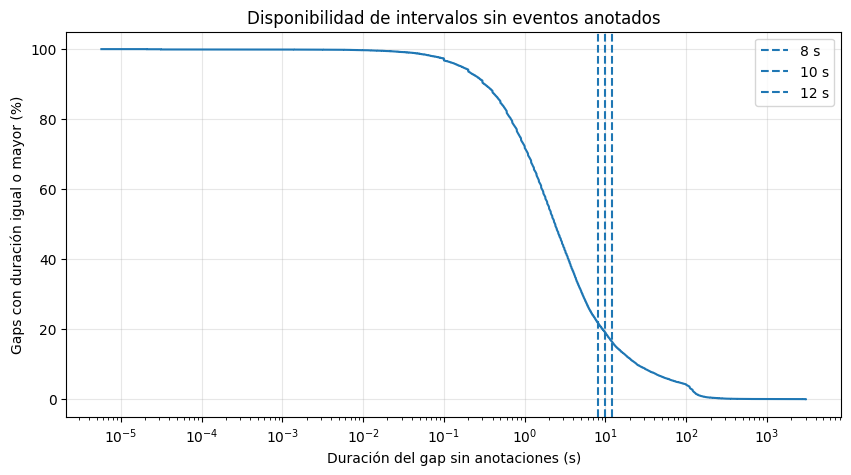

In [81]:
gaps_ordenados = np.sort(gaps_df["gap_s"].values)
porcentaje = (len(gaps_ordenados) - np.arange(len(gaps_ordenados))) / len(gaps_ordenados) * 100

plt.figure(figsize=(10, 5))
plt.step(gaps_ordenados, porcentaje, where="post")

plt.axvline(8, linestyle="--", label="8 s")
plt.axvline(10, linestyle="--", label="10 s")
plt.axvline(12, linestyle="--", label="12 s")

plt.xscale("log")
plt.xlabel("Duración del gap sin anotaciones (s)")
plt.ylabel("Gaps con duración igual o mayor (%)")
plt.title("Disponibilidad de intervalos sin eventos anotados")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

En torno a 8 - 12 segundos estamos aproximadamente entre 17% - 23%

El corpus contiene una cantidad considerable de regiones temporales sin eventos anotados. Aproximadamente el 72.7% de la duración total no está cubierta por bounding boxes, aunque existen diferencias entre datasets

PteroSet presenta alrededor de 90.8% de tiempo sin eventos anotados

Peru presenta solo 15.3%.

Además, existen 6065 gaps de al menos 8s, 5238 de al menos 10s y 4551 de al menos 12s, por lo que hay suficiente material potencial para construir muestras de fondo. Sin embargo, estos intervalos deben considerarse regiones sin anotaciones y no negativos confirmados, ya que la ausencia de bounding boxes no garantiza ausencia real de especies.

## Split

In [82]:
grabaciones_base = master_eda[["recording_uid", "dataset"]].drop_duplicates(subset=["recording_uid"]).copy()

especies_objetivo = master_eda[(master_eda["use_detector"] == True) & (~master_eda["name_specie"].isin(["OTHER_SPECIES", "UNDEFINED"]))]["name_specie"].unique()

for seed in range(1000):
    train_rec, temp_rec = train_test_split(grabaciones_base, test_size=0.30, random_state=seed, stratify=grabaciones_base["dataset"])
    val_rec, test_rec = train_test_split(temp_rec, test_size=0.50, random_state=seed, stratify=temp_rec["dataset"])

    train_rec["split"] = "train"
    val_rec["split"] = "validation"
    test_rec["split"] = "test"
    grabaciones_split = pd.concat([train_rec, val_rec, test_rec], ignore_index=True)
    master_split = master_eda.merge(grabaciones_split[["recording_uid", "split"]], on="recording_uid", how="left")
    cobertura = master_split[(master_split["use_detector"] == True) & (master_split["name_specie"].isin(especies_objetivo)) ].groupby(["name_specie", "split"])["recording_uid"].nunique().unstack(fill_value=0)

    for split in ["train", "validation", "test"]:
        if split not in cobertura.columns:
            cobertura[split] = 0

    if (cobertura[["train", "validation", "test"]] > 0).all().all():
        print("Seed encontrada:", seed)
        break

Seed encontrada: 0


Se obtuvo un split reproducible con random_state=0 que preserva la separación por grabación, mantiene ladistribución por dataset y garantiza representación de todas las especies en train, validation y test.

In [83]:
train_ids = set(grabaciones_split.loc[grabaciones_split["split"] == "train", "recording_uid"])
val_ids = set(grabaciones_split.loc[grabaciones_split["split"] == "validation", "recording_uid"])
test_ids = set(grabaciones_split.loc[grabaciones_split["split"] == "test", "recording_uid"])

leakage_resumen = pd.Series({
    "train_validation_compartidas": len(train_ids & val_ids),
    "train_test_compartidas": len(train_ids & test_ids),
    "validation_test_compartidas": len(val_ids & test_ids),
    "grabaciones_totales": len(grabaciones_split),
    "grabaciones_asignadas": len(train_ids | val_ids | test_ids)
})

leakage_resumen

,0
train_validation_compartidas,0
train_test_compartidas,0
validation_test_compartidas,0
grabaciones_totales,1011
grabaciones_asignadas,1011


In [84]:
resumen_split = grabaciones_split.groupby(["split", "dataset"]).size().unstack(fill_value=0)
resumen_split["total"] = resumen_split.sum(axis=1)
resumen_split["porcentaje_total"] = resumen_split["total"] / resumen_split["total"].sum() * 100
resumen_split

dataset,Col-CR,Peru,PteroSet,WABAD-CO,total,porcentaje_total
split,,,,,,
test,5,4,84,59,152,15.034619
train,24,14,394,275,707,69.930762
validation,5,3,85,59,152,15.034619


In [85]:
eventos_split = master_split[master_split["use_detector"] == True].copy()
especies_split = eventos_split.groupby(["name_specie", "split"])["recording_uid"].nunique().unstack(fill_value=0)

for split in ["train", "validation", "test"]:
    if split not in especies_split.columns:
        especies_split[split] = 0

especies_split = especies_split[["train", "validation", "test"]]
especies_split["total"] = especies_split.sum(axis=1)
especies_split["falta_validation"] = especies_split["validation"] == 0
especies_split["falta_test"] = especies_split["test"] == 0
especies_split.sort_values("total")

split,train,validation,test,total,falta_validation,falta_test
name_specie,,,,,,
dendrocolaptes certhia,13,1,1,15,False,False
empidonax virescens,12,1,4,17,False,False
leptotila rufaxilla,10,4,3,17,False,False
camptostoma obsoletum,13,4,2,19,False,False
patagioenas plumbea,14,2,3,19,False,False
xiphorhynchus guttatus,16,3,4,23,False,False
crypturellus soui,17,5,6,28,False,False
atlapetes schistaceus,20,7,2,29,False,False
nyctidromus albicollis,21,2,6,29,False,False


In [86]:
especies_split["falta_validation"].sum(), especies_split["falta_test"].sum()

(np.int64(0), np.int64(0))

Se definió un split 70/15/15 a nivel de `recording_uid`, evitando que eventos o ventanas provenientes de una misma grabación aparezcan en conjuntos diferentes. Con random_state=0 se obtuvieron 707 grabaciones para entrenamiento y 152 tanto para validación como para prueba, manteniendo representación de los cuatro datasets y de todas las especies en los tres conjuntos. No se detectó ningún recording_uid compartido entre splits. Algunas especies con pocas grabaciones presentan una representación reducida en validación o prueba, por lo que sus métricas individuales deberán interpretarse con mayor incertidumbre

# Conclusiones EDA

In [91]:
decisiones_eda = pd.DataFrame([
    {
        "aspecto": "Unidad de evaluación",
        "hallazgo": "Los eventos no son evidencia independiente, muchas especies tienen múltiples eventos dentro de las mismas grabaciones.",
        "decision": "El split debe realizarse por recording_uid, no por evento ni por ventana."
    },
    {
        "aspecto": "Split",
        "hallazgo": "Se obtuvo un split 70/15/15 con 707 grabaciones en train, 152 en validation y 152 en test, sin recording_uid compartidos.",
        "decision": "Usar random_state=0 y congelar este split para todos los experimentos futuros."
    },
    {
        "aspecto": "Duración de ventana",
        "hallazgo": "Las ventanas de 8, 10 y 12 segundos cubren aproximadamente 91.27%, 93.66% y 94.97% de los eventos focales, respectivamente.",
        "decision": "Usar 8 segundos como baseline inicial, conservar 10 y 12 segundos como posibles experimentos."
    },
    {
        "aspecto": "Densidad de objetos",
        "hallazgo": "Una ventana de 8 segundos contiene en promedio 4.02 bounding boxe, 10 segundos contiene 4.62 y 12 segundos contiene 5.23.",
        "decision": "El modelo debe tratarse como detector multi-bounding-box, no como clasificador de un único evento por ventana."
    },
    {
        "aspecto": "Coocurrencia",
        "hallazgo": "El 53.56% de los eventos se solapa temporalmente con otro evento y el 51.94% con otra especie.",
        "decision": "La coocurrencia debe considerarse un caso normal del problema, no una anomalía."
    },
    {
        "aspecto": "Solapamiento 2D",
        "hallazgo": "Aunque el 63.24% de los pares temporalmente solapados tienen algún IoU 2D, solo el 2.47% supera IoU ≥ 0.25 y el 0.216% supera IoU ≥ 0.50.",
        "decision": "La detección multi-evento es necesaria, pero los casos de fuerte superposición entre cajas son minoritarios."
    },
    {
        "aspecto": "Rango frecuencial",
        "hallazgo": "Los audios normalizados a 32 kHz permiten representar hasta 16 kHz por Nyquist. Ningún evento queda completamente por encima de 16 kHz.",
        "decision": "Usar 0–16 kHz como configuración conservadora inicial."
    },
    {
        "aspecto": "Candidatos espectrales",
        "hallazgo": "Cortes inferiores de 100–200 Hz no eliminan eventos completos, pero cortes mayores afectan especies de baja frecuencia. Cortes superiores de 12–14 kHz podrían reducir costo con pérdida limitada en varias especies.",
        "decision": "Mantener f_min ∈ {0, 100, 200} Hz y f_max ∈ {12, 14, 16} kHz como candidatos."
    },
    {
        "aspecto": "Fondo potencial",
        "hallazgo": "El corpus contiene aproximadamente 98.21 h sin eventos anotados, equivalentes al 72.66% de la duración total.",
        "decision": "Existen regiones candidatas para muestras de fondo, pero deben tratarse como intervalos sin anotación, no como negativos confirmados."
    },
    {
        "aspecto": "Gaps sin eventos",
        "hallazgo": "Existen 6065 gaps de al menos 8 segundos, 5238 de al menos 10 segundos y 4551 de al menos 12 segundos.",
        "decision": "Hay material suficiente para construir ventanas de fondo, especialmente para la configuración de 8 segundos."
    },
    {
        "aspecto": "Anotaciones inválidas",
        "hallazgo": "Se detectaron 32 eventos con duración temporal negativa.",
        "decision": "Estos eventos deben corregirse o excluirse antes del entrenamiento."
    }
])

# VER TODO EL DATAFRAME

with pd.option_context(
    'display.max_rows', None,  # Muestra todas las filas
    'display.max_columns', None,  # Muestra todas las columnas
    'display.max_colwidth', None, # Muestra todo el texto sin recortar párrafos
    'display.width', 1000# Evita que las columnas salten de línea
):
    display(decisiones_eda)


,aspecto,hallazgo,decision
0,Unidad de evaluación,"Los eventos no son evidencia independiente, muchas especies tienen múltiples eventos dentro de las mismas grabaciones.","El split debe realizarse por recording_uid, no por evento ni por ventana."
1,Split,"Se obtuvo un split 70/15/15 con 707 grabaciones en train, 152 en validation y 152 en test, sin recording_uid compartidos.",Usar random_state=0 y congelar este split para todos los experimentos futuros.
2,Duración de ventana,"Las ventanas de 8, 10 y 12 segundos cubren aproximadamente 91.27%, 93.66% y 94.97% de los eventos focales, respectivamente.","Usar 8 segundos como baseline inicial, conservar 10 y 12 segundos como posibles experimentos."
3,Densidad de objetos,"Una ventana de 8 segundos contiene en promedio 4.02 bounding boxe, 10 segundos contiene 4.62 y 12 segundos contiene 5.23.","El modelo debe tratarse como detector multi-bounding-box, no como clasificador de un único evento por ventana."
4,Coocurrencia,El 53.56% de los eventos se solapa temporalmente con otro evento y el 51.94% con otra especie.,"La coocurrencia debe considerarse un caso normal del problema, no una anomalía."
5,Solapamiento 2D,"Aunque el 63.24% de los pares temporalmente solapados tienen algún IoU 2D, solo el 2.47% supera IoU ≥ 0.25 y el 0.216% supera IoU ≥ 0.50.","La detección multi-evento es necesaria, pero los casos de fuerte superposición entre cajas son minoritarios."
6,Rango frecuencial,Los audios normalizados a 32 kHz permiten representar hasta 16 kHz por Nyquist. Ningún evento queda completamente por encima de 16 kHz.,Usar 0–16 kHz como configuración conservadora inicial.
7,Candidatos espectrales,"Cortes inferiores de 100–200 Hz no eliminan eventos completos, pero cortes mayores afectan especies de baja frecuencia. Cortes superiores de 12–14 kHz podrían reducir costo con pérdida limitada en varias especies.","Mantener f_min ∈ {0, 100, 200} Hz y f_max ∈ {12, 14, 16} kHz como candidatos."
8,Fondo potencial,"El corpus contiene aproximadamente 98.21 h sin eventos anotados, equivalentes al 72.66% de la duración total.","Existen regiones candidatas para muestras de fondo, pero deben tratarse como intervalos sin anotación, no como negativos confirmados."
9,Gaps sin eventos,"Existen 6065 gaps de al menos 8 segundos, 5238 de al menos 10 segundos y 4551 de al menos 12 segundos.","Hay material suficiente para construir ventanas de fondo, especialmente para la configuración de 8 segundos."


## Conclusión final

El EDA muestra que el corpus es adecuado para plantear un sistema de detección acústica multi-especie, pero también muestra varios retos importantes

En primer lugar, la partición de datos debe realizarse estrictamente a nivel de `recording_uid`. El análisis confirmó que dividir eventos o ventanas de una misma grabación entre train, validation y test produciría fuga de información. Se definió un split reproducible 70/15/15 con `random_state=0`, asignando 707 grabaciones a entrenamiento, 152 a validación y 152 a prueba, sin grabaciones compartidas entre conjuntos. Todas las especies quedaron representadas en los tres splits, aunque algunas especies con pocas grabaciones independientes tendrán métricas por clase más inestables.

En cuanto a la duración de entrada, las ventanas candidatas de 8, 10 y 12 segundos presentan una cobertura alta del evento focal, pero aumentar la ventana también incrementa la densidad de bounding boxes por muestra. Una ventana de 8 segundos contiene en promedio 4.02 cajas, mientras que 12 segundos contiene 5.23, además, el porcentaje de ventanas con al menos una caja truncada se mantiene alrededor del 72 % para las tres duraciones, así que aumentar la ventana no elimina el truncamiento, por esto, 8 segundos queda comocandidato razonable, manteniendo 10 y 12 segundos como experimentos.

El análisis de coocurrencia confirma que el problema no debe formularse como clasificación single-label de clips completos. El 53.56 % de los eventos se solapa temporalmente con otros eventos y el 51.94 % con eventos de otra especie, en ventanas de 8 segundos, el 85.30 % contiene al menos un evento adicional y el 66.82 % contiene otra especie. Entonces, la detección de múltiples eventos dentro de una misma entrada será un caso habitual, luego, el análisis de IoU 2D muestra que los solapamientos fuertes entre cajas son poco frecuentes, solo el 2.47 % de los pares temporalmente solapados alcanza IoU ≥ 0.25 y apenas el 0.216 % alcanza IoU ≥ 0.50. Esto nos dice que aunque la coocurrencia es común, muchos eventos siguen siendo relativamente separables en el plano tiempo-frecuencia.

En frecuencia, la configuración más conservadora es utilizar todo el rango disponible en los audios normalizados a 32 kHz, es decir, 0–16 kHz. El límite superior de 16 kHz está impuesto por Nyquist. Aunque 272 eventos tenían originalmente un `f_max_original` superior a 16 kHz, esto representa solo el 0.56 % del corpus y ningún evento estaba completamente por encima de dicho límite. Para experimentación posterior quedan como candidatos `f_min ∈ {0, 100, 200}` Hz y `f_max ∈ {12, 14, 16}` kHz.

El corpus también contiene una cantidad considerable de regiones sin eventos anotados, aproximadamente 98.21 h, equivalentes al 72.66 % de la duración total, no están cubiertas por bounding boxes. Existen miles de gaps suficientemente largos para construir ventanas de fondo de 8, 10 o 12 ssegundos, estos intervalos deben interpretarse como regiones sin anotación y no como negativos, porque la ausencia de bounding boxes no garantiza ausencia real de especies.

Finalmente, se detectaron 32 eventos con duración temporal negativa. Estas anotaciones son inválidas y deben corregirse o excluirse antes del entrenamiento. Las duraciones extremadamente largas y las diferencias entre datasets deben ser estudiadas a nivel de protocolo de dataset

El EDA recomienda iniciar el modelado con un detector multi-evento sobre ventanas de 8 segundos, usando el rango espectral completo 0–16 kHz, split fijo por `recording_uid` con `random_state=0`, y manejo explícito de múltiples bounding boxes por entrada. Las configuraciones de 10 y 12 segundos, así como los rangos frecuenciales más restrictivos, deben evaluarse mediante experimentos